#### Importing Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Data Cleaning and Analysis

In [32]:
df=pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx", sheet_name="Sheet1")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,1


<!-- #### Data Cleaning -->

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5494 non-null   object 
 1   MW                 5494 non-null   float64
 2   LogP               5494 non-null   float64
 3   NumHDonors         5494 non-null   int64  
 4   TPSA               5494 non-null   float64
 5   NumRotatableBonds  5494 non-null   int64  
 6   bioactivity        5494 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 300.6+ KB


In [16]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
count,5494,5494.000000,5494.000000,5494.000000,5494.000000,5494.000000,5494.000000
unique,5470,NaN,NaN,NaN,NaN,NaN,NaN
top,O=C(CCCCCNC(=O)NC(=O)c1ccc(NS(=O)(=O)c2ccccc2)...,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,432.121366,3.677190,2.885329,102.017377,7.740444,0.787404
std,NaN,120.641617,1.469028,1.200443,37.486733,3.452148,0.409181
min,NaN,75.067000,-14.260700,0.000000,7.760000,0.000000,0.000000
25%,NaN,354.415250,2.693300,2.000000,78.510000,5.000000,1.000000
50%,NaN,415.432000,3.646200,3.000000,97.555000,7.000000,1.000000
75%,NaN,492.605000,4.552330,3.000000,119.480000,10.000000,1.000000


In [17]:
df.isnull().sum()

canonical_smiles     0
MW                   0
LogP                 0
NumHDonors           0
TPSA                 0
NumRotatableBonds    0
bioactivity          0
dtype: int64

<!-- #### Model Training -->

##### Data Prep.

In [34]:
df.columns

Index(['canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'TPSA',
       'NumRotatableBonds', 'bioactivity'],
      dtype='object')

In [35]:
features_df = df.drop(['bioactivity'], axis=1)
target_df = df['bioactivity']

In [8]:
# fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
# axes = axes.flatten()

# for i, col in enumerate(numerical_cols):
#     axes[i].set_title(f'Distribution of {col} (KDE)')
#     sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()
#     axes[i].set_xlabel(col)
# plt.tight_layout()
# plt.show()

In [36]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile = row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['TPSA'], row['NumHDonors'],
                                                row['NumRotatableBonds']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(5494, 1029)

In [37]:
len(features_df), len(target_df)

(5494, 5494)

In [38]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [39]:
X.head(3)

,0,1,2,3,4,5,6,7,8,9,...,1019,1020,1021,1022,1023,1024,1025,1026,1027,1028
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,464.522,3.9242,129.65,4,11
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,485.544,4.4323,133.31,4,10
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,415.449,3.5662,107.53,4,7


<!-- ##### Train Test Split -->

In [40]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

FP_COLS = list(range(1024)) # fingerprint bit indices
DESC_COLS = list(range(1024, X_train.shape[1])) # descriptor indices


# Feature scaling (needed for some base estimators)

scaler = StandardScaler()
X_train = X_train.to_numpy().copy()
X_val = X_val.to_numpy().copy()
X_test = X_test.to_numpy().copy()

X_train[:, DESC_COLS] = scaler.fit_transform(X_train[:, DESC_COLS])
X_val [:, DESC_COLS] = scaler.transform(X_val [:, DESC_COLS])
X_test [:, DESC_COLS] = scaler.transform(X_test [:, DESC_COLS])

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)  
print(X_test.shape, y_test.shape)



(3845, 1029) (3845,)
(824, 1029) (824,)
(825, 1029) (825,)


In [ ]:
# cols_to_plot = X_train.columns[1000:1008]
# fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
# axes = axes.flatten()

# for i, col in enumerate(cols_to_plot):
#     sns.kdeplot(stat_x_train[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_title(f'Distribution of {col}')
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()

# plt.tight_layout()
# plt.show()

In [41]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

bioactivity
1    3028
0     817
Name: count, dtype: int64
bioactivity
1    645
0    179
Name: count, dtype: int64
bioactivity
1    653
0    172
Name: count, dtype: int64


##### Statistical Testing

In [15]:
y_train[y_train==0].value_counts().sum()/y_train.value_counts().sum()

0.21248374512353707

Generating t-SNE visualization...


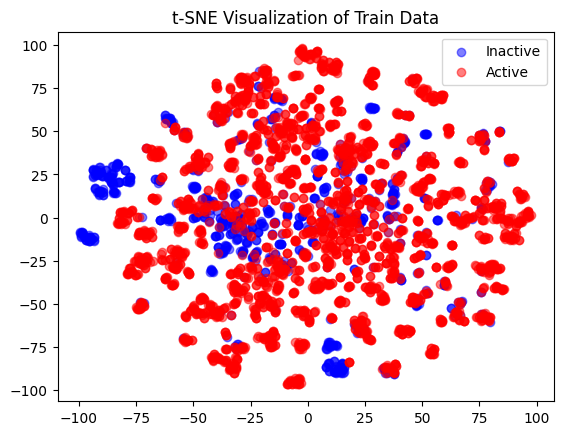

In [30]:
from sklearn.manifold import TSNE
print("Generating t-SNE visualization...")
# Use all features (embeddings + descriptors) for visualization
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_tsne = tsne.fit_transform(X_train)
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], label="Inactive", alpha=0.5, c='blue')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], label="Active", alpha=0.5, c='red')
plt.legend()
plt.title("t-SNE Visualization of Train Data")
plt.show()

e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


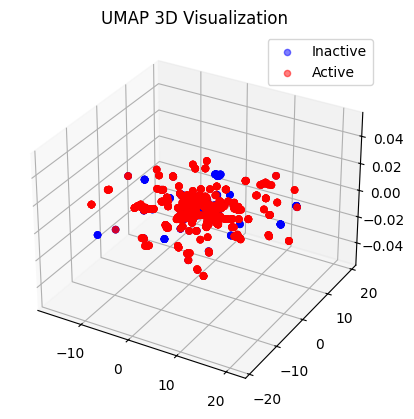

In [31]:
from umap.umap_ import UMAP
umap_model = UMAP(n_components=2, n_neighbors=7, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_train)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[y_train == 0, 0], X_umap[y_train == 0, 1],  c='blue', label="Inactive", alpha=0.5)
ax.scatter(X_umap[y_train == 1, 0], X_umap[y_train == 1, 1], c='red', label="Active", alpha=0.5)
ax.legend()
plt.title("UMAP 3D Visualization")
plt.show()

##### Utilities 

In [42]:
from sklearn.metrics import (
accuracy_score,
balanced_accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
matthews_corrcoef,
confusion_matrix,
average_precision_score,
cohen_kappa_score,
brier_score_loss
)
import os

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def plot_confusion_matrix(y_test, y_pred, model_name="model"):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_confusion_matrix.png"), dpi=150)
    plt.show()

def plot_roc_curve(y_test, y_prob, model_name="model"):
    from sklearn.metrics import RocCurveDisplay
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_roc_curve.png"), dpi=150)
    plt.show()

def plot_auprc_curve(y_test, y_prob, model_name="model"):
    from sklearn.metrics import PrecisionRecallDisplay
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('AUPRC Curve')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_auprc_curve.png"), dpi=150)
    plt.show()

def calc_metrics(final_model, model_name="model"):
    y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    y_pred = final_model.predict(X_test)  # Binary predictions (threshold at 0.5)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred, weights='quadratic')

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    npv = tn / (tn + fn) 
    specificity = tn / (tn + fp)
    sensitivity = recall  # same as recall
    informedness = sensitivity + specificity - 1

    dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

    brier = brier_score_loss(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Acc.: {balanced_acc:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUPRC: {auprc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"NPV: {npv:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print("Informedness: {:.4f}".format(informedness))
    print(f"DOR: {dor:.4f}")
    print(f"Brier Score: {brier:.4f}")

    print("********************")
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred, model_name=model_name)
    print("ROC Curve:")
    plot_roc_curve(y_test, y_prob, model_name=model_name)
    print("AUPRC Curve:")
    plot_auprc_curve(y_test, y_prob, model_name=model_name)

In [43]:
from sklearn.metrics import log_loss
import numpy as np
import torch
import torch.nn as nn

# Focal Loss for Imbalanced Data (Test Set)

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
        
def calc_loss(final_model):
    # Calculate log loss
    log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
    print("Log Loss(Test):", log_loss_value)

    log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
    print("Log Loss(Train):", log_loss_value)


    # Get predicted probabilities for the positive class
    y_proba = final_model.predict_proba(X_test)[:, 1]
    # Convert to logits (inverse of sigmoid)
    eps = 1e-8  # to avoid log(0)
    logits = np.log(y_proba / (1 - y_proba + eps) + eps)

    # Convert to torch tensors
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Calculate focal loss
    focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
    focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
    print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

In [44]:
from pathlib import Path
import joblib
import json

Path("saved_model/ml_models").mkdir(parents=True, exist_ok=True)

def save_model(final_model, best_params, model_name, model_path="ml_models"):
    # Create the directory if it doesn't exist
    Path(f"saved_model/{model_path}").mkdir(parents=True, exist_ok=True)

    # Save the trained model (with compression)
    joblib.dump(final_model, f"saved_model/{model_path}/{model_name}.pkl", compress=3)

    # Save simple metadata (e.g., columns and best params) for reproducibility
    metadata = {
        "model_type": type(final_model).__name__,
        "best_params": best_params if 'best_params' in globals() else None
    }
    with open(f"saved_model/{model_path}/{model_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Model and metadata saved to saved_model/{model_path}/")

In [45]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!



In [49]:
from lime.lime_tabular import LimeTabularExplainer

def lime_plot(final_model):
    def predict_proba_wrapper(X):
        return final_model.predict_proba(X)

    explainer = LimeTabularExplainer(
        X_train, 
        class_names=["0", "1"], 
        mode="classification"
    )


    exp = explainer.explain_instance(
        X_test[0], 
        predict_proba_wrapper,
        num_features=10
    )

    # OPTION 2: Show as matplotlib figure
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

    # OPTION 3: Print as text
    print("\nFeature contributions:")
    print(exp.as_list())

    # OPTION 4: Get as dictionary
    print("\nExplanation as dict:")
    print(exp.as_map())


##### XGBoost

In [51]:

import optuna
import warnings
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

N_CV_SPLITS  = 3    # folds inside each Optuna trial
N_TRIALS     = 20   # total Optuna trials
EARLY_STOP   = 20   # early stopping patience (rounds)
NUM_BOOST    = 1000 # upper bound; early stopping terminates before this
RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────────────────────
# Focal Loss — custom XGBoost objective
# ─────────────────────────────────────────────────────────────────────────────
def focal_loss_obj(gamma=2.0, alpha=0.5):
    def _obj(y_pred, dtrain):
        y_true  = dtrain.get_label()
        p       = 1.0 / (1.0 + np.exp(-y_pred))
        pt      = np.where(y_true == 1, p, 1.0 - p)
        alpha_t = np.where(y_true == 1, alpha, 1.0 - alpha)
        fw      = (1.0 - pt) ** gamma
        grad    = alpha_t * fw * (p - y_true)
        hess    = np.maximum(alpha_t * fw * p * (1.0 - p), 1e-6)
        return grad, hess
    return _obj


# ─────────────────────────────────────────────────────────────────────────────
# WeightedRandomSampler analogue for XGBoost
# ─────────────────────────────────────────────────────────────────────────────
def compute_sample_weights(y):
    classes, counts = np.unique(y, return_counts=True)
    N = len(y)
    weight_map = {c: N / (2.0 * cnt) for c, cnt in zip(classes, counts)}
    return np.array([weight_map[yi] for yi in y], dtype=np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# Custom early stopping callback
#
# XGBoost 2.x does NOT populate evals_log when using a custom obj= function,
# so the built-in EarlyStopping callback always raises "No metric named: val-auc".
# This callback bypasses evals_log entirely: it calls model.predict() directly,
# applies sigmoid, computes AUC, and stops when no improvement for `rounds`.
# It also stores the best AUC so objective() can return it (not the final-round AUC).
# ─────────────────────────────────────────────────────────────────────────────
class FocalEarlyStopping(xgb.callback.TrainingCallback):
    def __init__(self, dval, y_val, rounds):
        super().__init__()
        self.dval       = dval
        self.y_val      = y_val
        self.rounds     = rounds
        self.best_score = -np.inf
        self.best_round = 0

    def after_iteration(self, model, epoch, evals_log):
        raw   = model.predict(self.dval)
        p     = 1.0 / (1.0 + np.exp(-raw))
        score = roc_auc_score(self.y_val, p)

        if score > self.best_score:
            self.best_score = score
            self.best_round = epoch

        # Return True signals XGBoost to stop training
        return (epoch - self.best_round) >= self.rounds


neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
print(f"Class counts — negative: {neg_count}, positive: {pos_count}")

# Combine train+val; inverse-transform so per-fold scalers start from raw values
X_cv_raw = np.vstack([X_train, X_val]).copy()
X_cv_raw[:, DESC_COLS] = scaler.inverse_transform(X_cv_raw[:, DESC_COLS])
y_cv = np.concatenate([y_train, y_val])


def objective(trial, X_tr, y_tr, X_vf, y_vf, gamma, alpha):
    params = {
        "booster":          "gbtree",
        "learning_rate":    trial.suggest_float("learning_rate",    1e-3, 0.3,  log=True),
        "max_depth":        trial.suggest_int(  "max_depth",        3,    10),
        "min_child_weight": trial.suggest_int(  "min_child_weight", 1,    10),
        "subsample":        trial.suggest_float("subsample",        0.5,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3,  1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",        1e-2, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",       1e-2, 10.0, log=True),
        "nthread": -1, "verbosity": 0,
    }

    sw_tr = compute_sample_weights(y_tr)
    sw_vf = compute_sample_weights(y_vf)
    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=sw_tr)
    dval   = xgb.DMatrix(X_vf, label=y_vf, weight=sw_vf)

    obj_fn = focal_loss_obj(gamma=gamma, alpha=alpha)
    es_cb  = FocalEarlyStopping(dval, y_vf, EARLY_STOP)

    xgb.train(
        params, dtrain,
        num_boost_round=NUM_BOOST,
        obj=obj_fn,
        callbacks=[es_cb],
        verbose_eval=False,
    )

    # Return the best AUC seen during training (not the final-round AUC)
    return es_cb.best_score


def objective_cv(trial):
    gamma = trial.suggest_float("focal_gamma", 0.5, 5.0)
    alpha = trial.suggest_float("focal_alpha", 0.25, 0.75)

    fold   = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_cv_raw, y_cv)):
        X_tr, X_vf = X_cv_raw[tr_idx].copy(), X_cv_raw[val_idx].copy()
        y_tr, y_vf = y_cv[tr_idx], y_cv[val_idx]
        fs = StandardScaler()
        X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
        X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])
        score = objective(trial, X_tr, y_tr, X_vf, y_vf, gamma, alpha)
        scores.append(score)
        trial.report(np.mean(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study.optimize(objective_cv, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)


[I 2026-05-21 19:33:19,912] A new study created in memory with name: no-name-3b8ffaa4-57c9-4579-9439-7637f3137cbd


Class counts — negative: 817, positive: 3028


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.838354:   5%|▌         | 1/20 [00:01<00:34,  1.80s/it]

[I 2026-05-21 19:33:21,708] Trial 0 finished with value: 0.8383544749894604 and parameters: {'focal_gamma': 2.1854305348131313, 'focal_alpha': 0.7253571532049581, 'learning_rate': 0.06504856968981275, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.3406585285177396, 'reg_alpha': 3.9676050770529883, 'reg_lambda': 0.6358358856676253}. Best is trial 0 with value: 0.8383544749894604.


...

[I 2026-05-21 19:35:34,320] Trial 17 finished with value: 0.9102923465236161 and parameters: {'focal_gamma': 1.3065216445577355, 'focal_alpha': 0.575973453575597, 'learning_rate': 0.0034128835666668972, 'max_depth': 10, 'min_child_weight': 5, 'subsample': 0.9076737704598135, 'colsample_bytree': 0.8697955939044821, 'reg_alpha': 1.1928048056958864, 'reg_lambda': 0.1268556189984328}. Best is trial 12 with value: 0.9239127270720872.


Best trial: 12. Best value: 0.923913:  95%|█████████▌| 19/20 [02:22<00:12, 12.08s/it]

[I 2026-05-21 19:35:42,827] Trial 18 finished with value: 0.8988072039391394 and parameters: {'focal_gamma': 1.6009890634584723, 'focal_alpha': 0.33242887605287985, 'learning_rate': 0.013617644433575032, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.736061287588024, 'colsample_bytree': 0.6947822893150031, 'reg_alpha': 0.11919068675356752, 'reg_lambda': 0.015403608346350345}. Best is trial 12 with value: 0.9239127270720872.


Best trial: 12. Best value: 0.923913: 100%|██████████| 20/20 [02:30<00:00,  7.50s/it]

[I 2026-05-21 19:35:49,986] Trial 19 pruned. 
Best trial:
FrozenTrial(number=12, state=1, values=[0.9239127270720872], datetime_start=datetime.datetime(2026, 5, 21, 19, 33, 58, 664699), datetime_complete=datetime.datetime(2026, 5, 21, 19, 34, 17, 651497), params={'focal_gamma': 0.5632155611379308, 'focal_alpha': 0.48727607032495446, 'learning_rate': 0.006790660293301774, 'max_depth': 9, 'min_child_weight': 6, 'subsample': 0.6766980691634803, 'colsample_bytree': 0.6001950431325082, 'reg_alpha': 0.47735379415364093, 'reg_lambda': 0.09833826956146578}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9225866732235062, 1: 0.9220745743076346, 2: 0.9239127270720872}, distributions={'focal_gamma': FloatDistribution(high=5.0, log=False, low=0.5, step=None), 'focal_alpha': FloatDistribution(high=0.75, log=False, low=0.25, step=None), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_child_

In [52]:

# ── Train final XGBoost model on full train+val with Optuna best params ──────
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

best_params = study.best_params.copy()

# Extract focal loss hyperparams (Optuna searched them; not passed to xgb.train params)
best_gamma = best_params.pop("focal_gamma")
best_alpha = best_params.pop("focal_alpha")

print(f"Focal loss — gamma: {best_gamma:.4f}, alpha: {best_alpha:.4f}")

final_xgb_params = {
    "booster":   "gbtree",
    "verbosity": 0,
    "nthread":   -1,
    **best_params,
}

# X_train / X_val are already globally scaled — safe to stack directly
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# WeightedRandomSampler equivalent for final training
sw_full = compute_sample_weights(y_train_full)

dtrain_full = xgb.DMatrix(X_train_full, label=y_train_full, weight=sw_full)
dtest       = xgb.DMatrix(X_test,       label=y_test)

obj_fn = focal_loss_obj(gamma=best_gamma, alpha=best_alpha)

final_bst = xgb.train(
    final_xgb_params,
    dtrain_full,
    num_boost_round=NUM_BOOST,
    obj=obj_fn,
    verbose_eval=False,
)

# ─────────────────────────────────────────────────────────────────────────────
# BoosterWrapper — makes xgb.Booster look like an sklearn estimator.
#
# xgb.train() returns a raw Booster with no predict_proba() or sklearn-style
# predict().  All downstream utility functions (calc_metrics, calc_loss, SHAP,
# LIME, etc.) expect the sklearn interface, so we wrap the Booster here.
# ─────────────────────────────────────────────────────────────────────────────
class BoosterWrapper:
    """Wraps an xgb.Booster to expose predict_proba() and predict()."""
    def __init__(self, booster):
        self._bst = booster

    def _to_dmatrix(self, X):
        return xgb.DMatrix(X) if not isinstance(X, xgb.DMatrix) else X

    def predict_proba(self, X):
        """Returns array of shape [n, 2] — columns: [P(neg), P(pos)]."""
        raw  = self._bst.predict(self._to_dmatrix(X))
        pos  = 1.0 / (1.0 + np.exp(-raw))      # sigmoid for custom obj
        return np.column_stack([1.0 - pos, pos])

    def predict(self, X, threshold=0.5):
        """Returns binary predictions at the given threshold."""
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# Expose as final_model_xgb so downstream cells (calc_metrics, calc_loss,
# LIME, SHAP, etc.) that reference the old variable name continue to work.
final_model_xgb = BoosterWrapper(final_bst)

y_prob_test = final_model_xgb.predict_proba(X_test)[:, 1]
y_pred_test = final_model_xgb.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))


Focal loss — gamma: 0.5632, alpha: 0.4873
Test Accuracy: 0.9030
              precision    recall  f1-score   support

           0       0.82      0.68      0.75       172
           1       0.92      0.96      0.94       653

    accuracy                           0.90       825
   macro avg       0.87      0.82      0.84       825
weighted avg       0.90      0.90      0.90       825



In [55]:
calc_metrics(final_model_xgb, model_name="xgboost_final")


NameError: name 'final_model_xgb' is not defined

In [22]:
# Train loss uses X_train_full (what the model was actually trained on)
calc_loss(final_model_xgb)

# Override: show train-set log loss on the full training pool
from sklearn.metrics import log_loss
train_ll = log_loss(y_train_full, final_model_xgb.predict_proba(X_train_full))
print(f"Log Loss (Train+Val pool the model trained on): {train_ll:.4f}")


Log Loss(Test): 0.24225724189672423
Log Loss(Train): 0.15383616039861764
Focal Loss (Test Set): 0.0195
Log Loss (Train+Val pool the model trained on): 0.1546


In [23]:
save_model(final_model_xgb, final_xgb_params, "xgboost_bioactivity_model", model_path="xgboost")

Model and metadata saved to saved_model/xgboost/


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# 10-Fold Stratified Cross-Validation — XGBoost (Optuna Best Params)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    average_precision_score, cohen_kappa_score, brier_score_loss
)
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# ── 1. Reuse train+val pool prepared in cell 32 (X_test excluded — held out)
# X_cv_raw and y_cv are already inverse-transformed in cell 32; no re-scaling needed here
neg_cv = (y_cv == 0).sum()
pos_cv = (y_cv == 1).sum()
cv_scale_pos_weight = neg_cv / (pos_cv + 1e-8)

# ── 2. Build CV parameter dict from Optuna best params
cv_params = best_params.copy()
cv_params.update({
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "booster":          "gbtree",
    "scale_pos_weight": cv_scale_pos_weight,
    "n_jobs":           -1,
})

# ── 3. Run 10-Fold Stratified CV
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

METRIC_KEYS = [
    'Accuracy', 'Balanced Acc', 'Precision', 'Recall',
    'F1', 'ROC-AUC', 'AUPRC', 'MCC',
    'Sensitivity', 'Specificity', 'NPV', "Cohen's κ", 'Brier'
]
fold_metrics = {k: [] for k in METRIC_KEYS}

HDR = (f"{'Fold'!s:>5}  {'Acc'!s:>7}  {'Bal.Acc'!s:>8}  {'Prec'!s:>7}  {'Rec'!s:>7}  "
       f"{'F1'!s:>7}  {'AUC'!s:>7}  {'AUPRC'!s:>7}  "
       f"{'MCC'!s:>7}  {'Spec'!s:>7}  {'Kappa'!s:>7}  {'Brier'!s:>7}")
SEP = "=" * 100

print(SEP)
print("  10-Fold Stratified Cross-Validation — XGBoost | Train+Val only (X_test held out)")
print(SEP)
print(HDR)
print("-" * 100)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv_raw, y_cv), 1):
    X_tr, X_te = X_cv_raw[tr_idx].copy(), X_cv_raw[te_idx].copy()
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    # Scale descriptors within fold — prevents data leakage from other folds
    fold_scaler = StandardScaler()
    X_tr[:, DESC_COLS] = fold_scaler.fit_transform(X_tr[:, DESC_COLS])
    X_te[:, DESC_COLS] = fold_scaler.transform(X_te[:, DESC_COLS])

    # Train on fold
    model = xgb.XGBClassifier(**cv_params)
    model.fit(X_tr, y_tr, verbose=False)

    # Evaluate on held-out fold
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    acc   = accuracy_score(y_te, y_pred)
    bacc  = balanced_accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    sens  = tp / (tp + fn)  if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp)  if (tn + fp) > 0 else 0.0
    npv   = tn / (tn + fn)  if (tn + fn) > 0 else 0.0
    kappa = cohen_kappa_score(y_te, y_pred, weights='quadratic')
    brier = brier_score_loss(y_te, y_prob)

    vals = [acc, bacc, prec, rec, f1, auc, auprc, mcc, sens, spec, npv, kappa, brier]
    for k, v in zip(METRIC_KEYS, vals):
        fold_metrics[k].append(v)

    print(f"  {fold:>3d}  {acc:>7.4f}  {bacc:>8.4f}  {prec:>7.4f}  {rec:>7.4f}  "
          f"{f1:>7.4f}  {auc:>7.4f}  {auprc:>7.4f}  "
          f"{mcc:>7.4f}  {spec:>7.4f}  {kappa:>7.4f}  {brier:>7.4f}")

print(SEP)

# ── 4. Full summary table (mean ± std, min, max)
print('''
━━━  Per-Metric Summary (all 13 metrics)  ━━━
''')
summary_rows = []
for k in METRIC_KEYS:
    arr = np.array(fold_metrics[k])
    summary_rows.append({
        'Metric':     k,
        'Mean ± Std': f"{arr.mean():.4f} ± {arr.std():.4f}",
        'Min':        f"{arr.min():.4f}",
        'Max':        f"{arr.max():.4f}",
        '95% CI':     f"[{arr.mean()-1.96*arr.std()/np.sqrt(N_SPLITS):.4f}, "
                       f"{arr.mean()+1.96*arr.std()/np.sqrt(N_SPLITS):.4f}]"
    })

summary_df = pd.DataFrame(summary_rows).set_index('Metric')
print(summary_df.to_string())

# ── 5. Compact paper-ready one-row table
print('''
━━━  Paper-Ready Summary (Key Metrics Only)  ━━━
''')
paper_keys = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC', 'Sensitivity', 'Specificity', "Cohen's κ", 'Brier']
paper_row = {k: f"{np.mean(fold_metrics[k]):.4f} ± {np.std(fold_metrics[k]):.4f}" for k in paper_keys}
paper_df = pd.DataFrame([paper_row], index=['XGBoost (10-Fold CV)'])
print(paper_df.T.to_string())
print()

# ── 6. Store for later comparison across models
xgb_cv_results = {k: np.array(v) for k, v in fold_metrics.items()}
print('''
[INFO] Cross-validation results stored in  dict for multi-model comparison.''')


  10-Fold Stratified Cross-Validation — XGBoost | Train+Val only (X_test held out)
 Fold      Acc   Bal.Acc     Prec      Rec       F1      AUC    AUPRC      MCC     Spec    Kappa    Brier
----------------------------------------------------------------------------------------------------


    1   0.9293    0.8666   0.9373   0.9755   0.9561   0.9640   0.9893   0.7801   0.7576   0.7761   0.0582
    2   0.8994    0.8734   0.9521   0.9185   0.9350   0.9418   0.9785   0.7148   0.8283   0.7126   0.0784
    3   0.9336    0.9025   0.9591   0.9565   0.9578   0.9614   0.9878   0.8021   0.8485   0.8020   0.0602
    4   0.9251    0.8941   0.9560   0.9482   0.9521   0.9550   0.9848   0.7799   0.8400   0.7797   0.0629
    5   0.9272    0.9028   0.9612   0.9455   0.9533   0.9492   0.9777   0.7888   0.8600   0.7883   0.0681
    6   0.8972    0.8837   0.9597   0.9074   0.9328   0.9583   0.9837   0.7204   0.8600   0.7153   0.0708
    7   0.9272    0.9064   0.9638   0.9428   0.9532   0.9683   0.9901   0.7908   0.8700   0.7898   0.0598
    8   0.9122    0.8787   0.9503   0.9373   0.9438   0.9416   0.9807   0.7442   0.8200   0.7438   0.0701
    9   0.9101    0.8846   0.9552   0.9292   0.9420   0.9607   0.9874   0.7436   0.8400   0.7422   0.0646
   10   0.9292    0.9145   0.9691   0.9401   0

##### RandomForest

In [25]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings; warnings.filterwarnings("ignore")

N_CV_SPLITS = 3
N_TRIALS    = 20

def objective_rf(trial, X_tr, y_tr, X_vf, y_vf):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": RANDOM_STATE, "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_tr, y_tr)
    return roc_auc_score(y_vf, model.predict_proba(X_vf)[:, 1])

def objective_cv_rf(trial):
    fold = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_cv_raw, y_cv)):
        score = objective_rf(trial, X_cv_raw[tr_idx], y_cv[tr_idx],
                                    X_cv_raw[val_idx], y_cv[val_idx])
        scores.append(score)
        trial.report(np.mean(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study_rf = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study_rf.optimize(objective_cv_rf, n_trials=N_TRIALS, show_progress_bar=True)
print("Best params:", study_rf.best_params)


[I 2026-05-16 11:07:22,616] A new study created in memory with name: no-name-bdcda6c9-aa3c-4e7a-ad17-c42954720191
Best trial: 0. Best value: 0.944501:   5%|▌         | 1/20 [00:01<00:33,  1.74s/it]

[I 2026-05-16 11:07:24,360] Trial 0 finished with value: 0.9445007715268169 and parameters: {'n_estimators': 287, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9445007715268169.


Best trial: 1. Best value: 0.955968:  10%|█         | 2/20 [00:06<00:59,  3.32s/it]

[I 2026-05-16 11:07:28,779] Trial 1 finished with value: 0.955968493823232 and parameters: {'n_estimators': 585, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.5, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.955968493823232.


Best trial: 1. Best value: 0.955968:  15%|█▌        | 3/20 [00:07<00:44,  2.60s/it]

...

[I 2026-05-16 11:08:20,278] Trial 17 finished with value: 0.9573827958224789 and parameters: {'n_estimators': 359, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 17 with value: 0.9573827958224789.


Best trial: 17. Best value: 0.957383:  95%|█████████▌| 19/20 [00:59<00:03,  3.11s/it]

[I 2026-05-16 11:08:22,305] Trial 18 pruned. 


Best trial: 17. Best value: 0.957383: 100%|██████████| 20/20 [01:02<00:00,  3.12s/it]

[I 2026-05-16 11:08:25,085] Trial 19 pruned. 
Best params: {'n_estimators': 359, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'criterion': 'gini', 'class_weight': 'balanced'}


In [26]:
# ── Final RandomForest on full train+val with Optuna best params ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

best_params_rf = study_rf.best_params.copy()
best_params_rf.update({"random_state": RANDOM_STATE, "n_jobs": -1})

X_train_full = np.vstack([X_train, X_val])
y_train_full  = np.concatenate([y_train, y_val])

final_model_rf = RandomForestClassifier(**best_params_rf)
final_model_rf.fit(X_train_full, y_train_full)

print(f"Test Accuracy: {accuracy_score(y_test, final_model_rf.predict(X_test)):.4f}")
print(classification_report(y_test, final_model_rf.predict(X_test)))


Test Accuracy: 0.9224
              precision    recall  f1-score   support

           0       0.86      0.76      0.80       172
           1       0.94      0.97      0.95       653

    accuracy                           0.92       825
   macro avg       0.90      0.86      0.88       825
weighted avg       0.92      0.92      0.92       825



In [27]:
# ===========================================================================
# 10-Fold Stratified CV — RandomForest (Optuna Best Params)
# ===========================================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    average_precision_score, cohen_kappa_score, brier_score_loss,
)
import warnings; warnings.filterwarnings("ignore")

# X_cv_raw / y_cv: train+val pool (unscaled); X_test held out
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

METRIC_KEYS = [
    "Accuracy", "Balanced Acc", "Precision", "Recall",
    "F1", "ROC-AUC", "AUPRC", "MCC",
    "Sensitivity", "Specificity", "NPV", "Cohen s k", "Brier",
]
fold_metrics = {k: [] for k in METRIC_KEYS}

HDR = (f"{'Fold':>5}  {'Acc':>7}  {'Bal.Acc':>8}  {'Prec':>7}  {'Rec':>7}  "
       f"{'F1':>7}  {'AUC':>7}  {'AUPRC':>7}  {'MCC':>7}  {'Spec':>7}  "
       f"{'Kappa':>7}  {'Brier':>7}")
SEP = "=" * 100
print(SEP)
print("  10-Fold CV — RandomForest | Train+Val only (X_test held out)")
print(SEP); print(HDR); print("-" * 100)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv_raw, y_cv), 1):
    X_tr, X_te = X_cv_raw[tr_idx].copy(), X_cv_raw[te_idx].copy()
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    model = RandomForestClassifier(**best_params_rf)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    acc   = accuracy_score(y_te, y_pred)
    bacc  = balanced_accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv   = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    kappa = cohen_kappa_score(y_te, y_pred, weights="quadratic")
    brier = brier_score_loss(y_te, y_prob)

    vals = [acc, bacc, prec, rec, f1, auc, auprc, mcc, sens, spec, npv, kappa, brier]
    for k, v in zip(METRIC_KEYS, vals):
        fold_metrics[k].append(v)

    print(f"  {fold:>3}  {acc:>7.4f}  {bacc:>8.4f}  {prec:>7.4f}  {rec:>7.4f}  "
          f"{f1:>7.4f}  {auc:>7.4f}  {auprc:>7.4f}  {mcc:>7.4f}  {spec:>7.4f}  "
          f"{kappa:>7.4f}  {brier:>7.4f}")

print(SEP)
print("\n  Per-Metric Summary\n")
rows = []
for k in METRIC_KEYS:
    arr = np.array(fold_metrics[k])
    rows.append({"Metric": k,
                  "Mean +- Std": f"{arr.mean():.4f} +- {arr.std():.4f}",
                  "Min": f"{arr.min():.4f}", "Max": f"{arr.max():.4f}",
                  "95% CI": f"[{arr.mean()-1.96*arr.std()/np.sqrt(N_SPLITS):.4f}, "
                             f"{arr.mean()+1.96*arr.std()/np.sqrt(N_SPLITS):.4f}]"})
print(pd.DataFrame(rows).set_index("Metric").to_string())

print("\n  Paper-Ready Summary\n")
paper_keys = ["Accuracy", "ROC-AUC", "F1", "MCC", "AUPRC", "Sensitivity", "Specificity", "Cohen s k", "Brier"]
paper_row  = {k: f"{np.mean(fold_metrics[k]):.4f} +- {np.std(fold_metrics[k]):.4f}" for k in paper_keys}
print(pd.DataFrame([paper_row], index=["RandomForest (10-Fold CV)"]).T.to_string())

rf_cv_results = {k: np.array(v) for k, v in fold_metrics.items()}
print("\n[INFO] Results stored in rf_cv_results")


  10-Fold CV — RandomForest | Train+Val only (X_test held out)
 Fold      Acc   Bal.Acc     Prec      Rec       F1      AUC    AUPRC      MCC     Spec    Kappa    Brier
----------------------------------------------------------------------------------------------------
    1   0.9165    0.8252   0.9165   0.9837   0.9489   0.9751   0.9930   0.7361   0.6667   0.7224   0.0566
    2   0.9143    0.8681   0.9432   0.9484   0.9458   0.9434   0.9801   0.7418   0.7879   0.7417   0.0680
    3   0.9336    0.8840   0.9469   0.9701   0.9584   0.9679   0.9906   0.7959   0.7980   0.7945   0.0545
    4   0.9358    0.8755   0.9399   0.9809   0.9600   0.9583   0.9861   0.8020   0.7700   0.7973   0.0587
    5   0.9293    0.8787   0.9441   0.9673   0.9556   0.9568   0.9841   0.7843   0.7900   0.7829   0.0600
    6   0.9293    0.8859   0.9489   0.9619   0.9553   0.9612   0.9853   0.7866   0.8100   0.7862   0.0615
    7   0.9358    0.8864   0.9469   0.9728   0.9597   0.9698   0.9911   0.8037   0.8000   0.80

Accuracy: 0.9224
Balanced Acc.: 0.8611
Cohen's Kappa: 0.7544
Precision: 0.9376
Recall: 0.9663
F1 Score: 0.9517
ROC-AUC: 0.9636
AUPRC: 0.9899
MCC: 0.7567
NPV: 0.8553
Specificity: 0.7558
Sensitivity: 0.9663
Informedness: 0.7221
DOR: 88.7771
Brier Score: 0.0615
********************
Confusion Matrix:


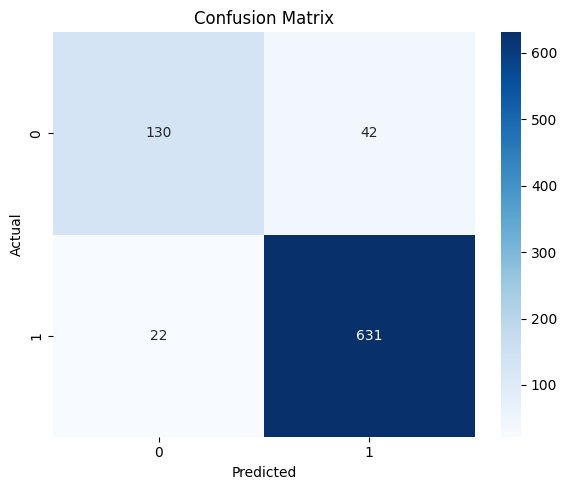

ROC Curve:


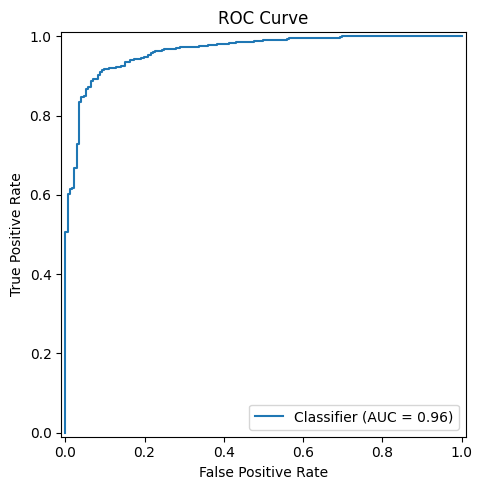

AUPRC Curve:


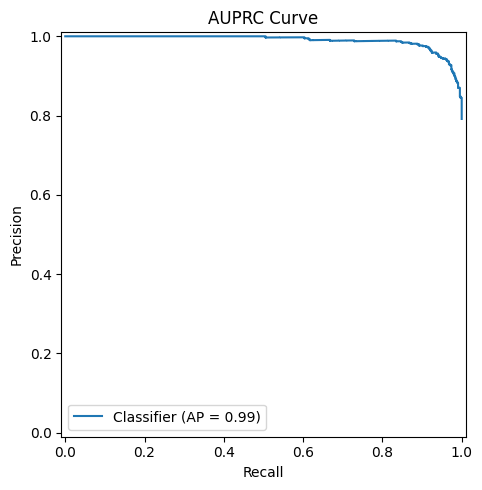

In [28]:
calc_metrics(final_model_rf)

In [29]:
# Train loss on the full pool the model was trained on
calc_loss(final_model_rf)

from sklearn.metrics import log_loss
import numpy as np
train_ll = log_loss(y_train_full, final_model_rf.predict_proba(X_train_full))
print(f"Log Loss (Train+Val pool): {train_ll:.4f}")


Log Loss(Test): 0.21926754949666247
Log Loss(Train): 0.10338410551969475
Focal Loss (Test Set): 0.0165
Log Loss (Train+Val pool): 0.1048


In [30]:
save_model(final_model_rf, best_params_rf, "random_forest_bioactivity_model", model_path="rf")

Model and metadata saved to saved_model/rf/


##### LightGBM

In [31]:
import optuna
import numpy as np
import lightgbm as lgbm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings; warnings.filterwarnings("ignore")

N_CV_SPLITS = 3
N_TRIALS    = 20

def objective_lgbm(trial, X_tr, y_tr, X_vf, y_vf):
    params = {
        "boosting_type":     "gbdt",
        "objective":         "binary",
        "metric":            "auc",
        "verbosity":         -1,
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "num_leaves":        trial.suggest_int("num_leaves", 7, 127),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "scale_pos_weight":  scale_pos_weight,
        "n_jobs": -1,
    }
    model = lgbm.LGBMClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_vf, y_vf)],
              callbacks=[lgbm.early_stopping(20, verbose=False),
                         lgbm.log_evaluation(-1)])
    return roc_auc_score(y_vf, model.predict_proba(X_vf)[:, 1])

def objective_cv_lgbm(trial):
    fold = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_cv_raw, y_cv)):
        score = objective_lgbm(trial, X_cv_raw[tr_idx], y_cv[tr_idx],
                                      X_cv_raw[val_idx], y_cv[val_idx])
        scores.append(score)
        trial.report(np.mean(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study_lgbm.optimize(objective_cv_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Best params:", study_lgbm.best_params)


[I 2026-05-16 11:44:16,812] A new study created in memory with name: no-name-e0199bdb-71be-45a5-af63-7dc1ea69fdbf
Best trial: 0. Best value: 0.950206:   5%|▌         | 1/20 [00:23<07:21, 23.22s/it]

[I 2026-05-16 11:44:40,044] Trial 0 finished with value: 0.9502057737418931 and parameters: {'n_estimators': 300, 'max_depth': 12, 'num_leaves': 95, 'learning_rate': 0.030405325392865647, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 0.014936568554617643, 'reg_lambda': 3.9676050770529883, 'min_child_samples': 32}. Best is trial 0 with value: 0.9502057737418931.


Best trial: 0. Best value: 0.950206:  10%|█         | 2/20 [00:47<07:13, 24.10s/it]

[I 2026-05-16 11:45:04,759] Trial 1 finished with value: 0.9444325638555288 and parameters: {'n_estimators': 450, 'max_depth': 3, 'num_leaves': 124, 'learning_rate': 0.11536162338241392, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_alpha': 0.03549878832196503, 'reg_lambda': 0.08179499475211674, 'min_child_samples': 29}. Best is trial 0 with value: 0.9502057737418931.


Best trial: 0. Best value: 0.950206:  15%|█▌        | 3/20 [00:57<04:59, 17.62s/it]

...

[I 2026-05-16 11:48:56,654] Trial 17 finished with value: 0.9527476706880879 and parameters: {'n_estimators': 500, 'max_depth': 7, 'num_leaves': 28, 'learning_rate': 0.05946454514259866, 'subsample': 0.8349442292350789, 'colsample_bytree': 0.749690871893853, 'reg_alpha': 0.7625344687909923, 'reg_lambda': 0.22970610276800438, 'min_child_samples': 6}. Best is trial 16 with value: 0.9565619192790905.


Best trial: 16. Best value: 0.956562:  95%|█████████▌| 19/20 [05:02<00:18, 18.04s/it]

[I 2026-05-16 11:49:19,110] Trial 18 finished with value: 0.9554295921849328 and parameters: {'n_estimators': 550, 'max_depth': 8, 'num_leaves': 56, 'learning_rate': 0.05163551828253074, 'subsample': 0.7175149564621902, 'colsample_bytree': 0.9249768164883356, 'reg_alpha': 0.49195354798568025, 'reg_lambda': 0.028350452075139525, 'min_child_samples': 6}. Best is trial 16 with value: 0.9565619192790905.


Best trial: 16. Best value: 0.956562: 100%|██████████| 20/20 [05:38<00:00, 16.91s/it]

[I 2026-05-16 11:49:55,039] Trial 19 pruned. 
Best params: {'n_estimators': 500, 'max_depth': 8, 'num_leaves': 29, 'learning_rate': 0.06480007916836178, 'subsample': 0.6888978330497283, 'colsample_bytree': 0.7884745869448389, 'reg_alpha': 0.07322098969970543, 'reg_lambda': 0.14665861669762495, 'min_child_samples': 5}


In [32]:
# ── Final LightGBM on full train+val with Optuna best params ──
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

best_params_lgbm = study_lgbm.best_params.copy()
best_params_lgbm.update({
    "boosting_type": "gbdt", "objective": "binary",
    "metric": "auc", "verbosity": -1,
    "scale_pos_weight": scale_pos_weight, "n_jobs": -1,
})

X_train_full = np.vstack([X_train, X_val])
y_train_full  = np.concatenate([y_train, y_val])

final_model_lgbm = lgbm.LGBMClassifier(**best_params_lgbm)
final_model_lgbm.fit(X_train_full, y_train_full,
                     callbacks=[lgbm.log_evaluation(-1)])

print(f"Test Accuracy: {accuracy_score(y_test, final_model_lgbm.predict(X_test)):.4f}")
print(classification_report(y_test, final_model_lgbm.predict(X_test)))


Test Accuracy: 0.9273
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       172
           1       0.96      0.95      0.95       653

    accuracy                           0.93       825
   macro avg       0.89      0.89      0.89       825
weighted avg       0.93      0.93      0.93       825



In [33]:
# ===========================================================================
# 10-Fold Stratified CV — LightGBM (Optuna Best Params)
# ===========================================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    average_precision_score, cohen_kappa_score, brier_score_loss,
)
import warnings; warnings.filterwarnings("ignore")

# X_cv_raw / y_cv: train+val pool (unscaled); X_test held out
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

METRIC_KEYS = [
    "Accuracy", "Balanced Acc", "Precision", "Recall",
    "F1", "ROC-AUC", "AUPRC", "MCC",
    "Sensitivity", "Specificity", "NPV", "Cohen s k", "Brier",
]
fold_metrics = {k: [] for k in METRIC_KEYS}

HDR = (f"{'Fold':>5}  {'Acc':>7}  {'Bal.Acc':>8}  {'Prec':>7}  {'Rec':>7}  "
       f"{'F1':>7}  {'AUC':>7}  {'AUPRC':>7}  {'MCC':>7}  {'Spec':>7}  "
       f"{'Kappa':>7}  {'Brier':>7}")
SEP = "=" * 100
print(SEP)
print("  10-Fold CV — LightGBM | Train+Val only (X_test held out)")
print(SEP); print(HDR); print("-" * 100)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv_raw, y_cv), 1):
    X_tr, X_te = X_cv_raw[tr_idx].copy(), X_cv_raw[te_idx].copy()
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    model = lgbm.LGBMClassifier(**best_params_lgbm)
    model.fit(X_tr, y_tr, callbacks=[lgbm.log_evaluation(-1)])

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    acc   = accuracy_score(y_te, y_pred)
    bacc  = balanced_accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv   = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    kappa = cohen_kappa_score(y_te, y_pred, weights="quadratic")
    brier = brier_score_loss(y_te, y_prob)

    vals = [acc, bacc, prec, rec, f1, auc, auprc, mcc, sens, spec, npv, kappa, brier]
    for k, v in zip(METRIC_KEYS, vals):
        fold_metrics[k].append(v)

    print(f"  {fold:>3}  {acc:>7.4f}  {bacc:>8.4f}  {prec:>7.4f}  {rec:>7.4f}  "
          f"{f1:>7.4f}  {auc:>7.4f}  {auprc:>7.4f}  {mcc:>7.4f}  {spec:>7.4f}  "
          f"{kappa:>7.4f}  {brier:>7.4f}")

print(SEP)
print("\n  Per-Metric Summary\n")
rows = []
for k in METRIC_KEYS:
    arr = np.array(fold_metrics[k])
    rows.append({"Metric": k,
                  "Mean +- Std": f"{arr.mean():.4f} +- {arr.std():.4f}",
                  "Min": f"{arr.min():.4f}", "Max": f"{arr.max():.4f}",
                  "95% CI": f"[{arr.mean()-1.96*arr.std()/np.sqrt(N_SPLITS):.4f}, "
                             f"{arr.mean()+1.96*arr.std()/np.sqrt(N_SPLITS):.4f}]"})
print(pd.DataFrame(rows).set_index("Metric").to_string())

print("\n  Paper-Ready Summary\n")
paper_keys = ["Accuracy", "ROC-AUC", "F1", "MCC", "AUPRC", "Sensitivity", "Specificity", "Cohen s k", "Brier"]
paper_row  = {k: f"{np.mean(fold_metrics[k]):.4f} +- {np.std(fold_metrics[k]):.4f}" for k in paper_keys}
print(pd.DataFrame([paper_row], index=["LightGBM (10-Fold CV)"]).T.to_string())

lgbm_cv_results = {k: np.array(v) for k, v in fold_metrics.items()}
print("\n[INFO] Results stored in lgbm_cv_results")


  10-Fold CV — LightGBM | Train+Val only (X_test held out)
 Fold      Acc   Bal.Acc     Prec      Rec       F1      AUC    AUPRC      MCC     Spec    Kappa    Brier
----------------------------------------------------------------------------------------------------
    1   0.9358    0.8706   0.9378   0.9837   0.9602   0.9688   0.9911   0.8002   0.7576   0.7940   0.0530
    2   0.9315    0.8901   0.9516   0.9620   0.9568   0.9575   0.9815   0.7921   0.8182   0.7918   0.0563
    3   0.9229    0.8809   0.9486   0.9538   0.9512   0.9603   0.9870   0.7676   0.8081   0.7676   0.0554
    4   0.9358    0.8937   0.9517   0.9673   0.9595   0.9602   0.9871   0.8055   0.8200   0.8049   0.0528
    5   0.9422    0.8977   0.9521   0.9755   0.9637   0.9610   0.9847   0.8238   0.8200   0.8224   0.0480
    6   0.9422    0.9123   0.9620   0.9646   0.9633   0.9676   0.9868   0.8276   0.8600   0.8276   0.0476
    7   0.9443    0.9173   0.9646   0.9646   0.9646   0.9681   0.9855   0.8346   0.8700   0.8346  

Accuracy: 0.9273
Balanced Acc.: 0.8941
Cohen's Kappa: 0.7815
Precision: 0.9569
Recall: 0.9510
F1 Score: 0.9539
ROC-AUC: 0.9612
AUPRC: 0.9889
MCC: 0.7816
NPV: 0.8182
Specificity: 0.8372
Sensitivity: 0.9510
Informedness: 0.7882
DOR: 99.8036
Brier Score: 0.0582
********************
Confusion Matrix:


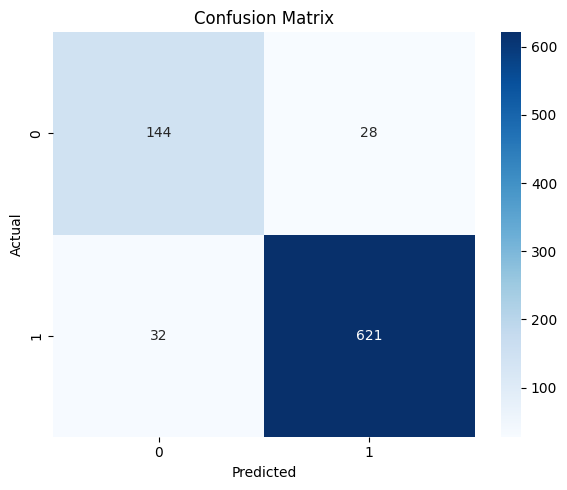

ROC Curve:


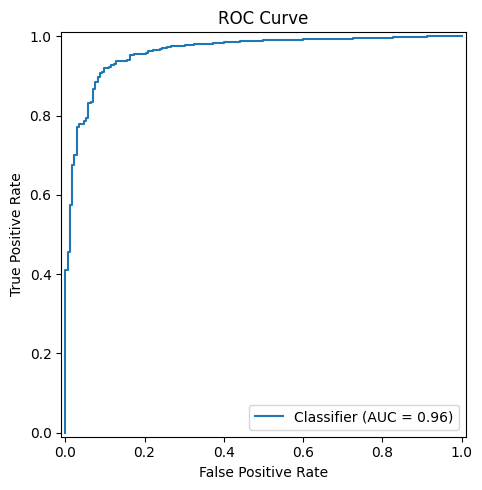

AUPRC Curve:


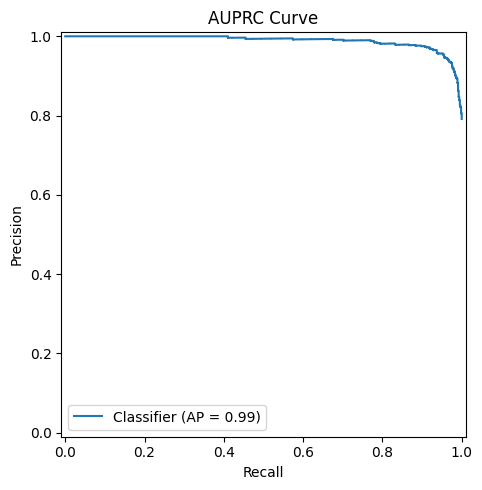

In [34]:
calc_metrics(final_model_lgbm)

In [35]:
# Train loss on the full pool the model was trained on
calc_loss(final_model_lgbm)

from sklearn.metrics import log_loss
import numpy as np
train_ll = log_loss(y_train_full, final_model_lgbm.predict_proba(X_train_full))
print(f"Log Loss (Train+Val pool): {train_ll:.4f}")


Log Loss(Test): 0.21411054346195876
Log Loss(Train): 0.03024007079924459
Focal Loss (Test Set): 0.0349
Log Loss (Train+Val pool): 0.0314


In [36]:
save_model(final_model_lgbm, best_params_lgbm, "lightgbm_bioactivity_model", model_path="lgbm")

Model and metadata saved to saved_model/lgbm/


##### CatBoost

In [ ]:
import optuna
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings; warnings.filterwarnings("ignore")

N_CV_SPLITS = 3
N_TRIALS    = 20

def objective_cat(trial, X_tr, y_tr, X_vf, y_vf):
    params = {
        "iterations":          trial.suggest_int("iterations", 100, 800),
        "depth":               trial.suggest_int("depth", 3, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 2.0),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "scale_pos_weight":    scale_pos_weight,
        "eval_metric":         "AUC",
        "verbose":             False,
        "thread_count":        -1,
        "random_seed":         RANDOM_STATE,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=(X_vf, y_vf),
              early_stopping_rounds=20, verbose=False)
    return roc_auc_score(y_vf, model.predict_proba(X_vf)[:, 1])

def objective_cv_cat(trial):
    fold = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_cv_raw, y_cv)):
        score = objective_cat(trial, X_cv_raw[tr_idx], y_cv[tr_idx],
                                     X_cv_raw[val_idx], y_cv[val_idx])
        scores.append(score)
        trial.report(np.mean(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study_cat = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study_cat.optimize(objective_cv_cat, n_trials=N_TRIALS, show_progress_bar=True)
print("Best params:", study_cat.best_params)


In [ ]:
# ── Final CatBoost on full train+val with Optuna best params ──
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

best_params_cat = study_cat.best_params.copy()
best_params_cat.update({
    "eval_metric": "AUC", "verbose": False,
    "thread_count": -1, "random_seed": RANDOM_STATE,
    "scale_pos_weight": scale_pos_weight,
})

X_train_full = np.vstack([X_train, X_val])
y_train_full  = np.concatenate([y_train, y_val])

final_model_cat = CatBoostClassifier(**best_params_cat)
final_model_cat.fit(X_train_full, y_train_full, verbose=False)

print(f"Test Accuracy: {accuracy_score(y_test, final_model_cat.predict(X_test)):.4f}")
print(classification_report(y_test, final_model_cat.predict(X_test)))


In [ ]:
# ===========================================================================
# 10-Fold Stratified CV — CatBoost (Optuna Best Params)
# ===========================================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    average_precision_score, cohen_kappa_score, brier_score_loss,
)
import warnings; warnings.filterwarnings("ignore")

# X_cv_raw / y_cv: train+val pool (unscaled); X_test held out
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

METRIC_KEYS = [
    "Accuracy", "Balanced Acc", "Precision", "Recall",
    "F1", "ROC-AUC", "AUPRC", "MCC",
    "Sensitivity", "Specificity", "NPV", "Cohen s k", "Brier",
]
fold_metrics = {k: [] for k in METRIC_KEYS}

HDR = (f"{'Fold':>5}  {'Acc':>7}  {'Bal.Acc':>8}  {'Prec':>7}  {'Rec':>7}  "
       f"{'F1':>7}  {'AUC':>7}  {'AUPRC':>7}  {'MCC':>7}  {'Spec':>7}  "
       f"{'Kappa':>7}  {'Brier':>7}")
SEP = "=" * 100
print(SEP)
print("  10-Fold CV — CatBoost | Train+Val only (X_test held out)")
print(SEP); print(HDR); print("-" * 100)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv_raw, y_cv), 1):
    X_tr, X_te = X_cv_raw[tr_idx].copy(), X_cv_raw[te_idx].copy()
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    model = CatBoostClassifier(**best_params_cat)
    model.fit(X_tr, y_tr, verbose=False)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    acc   = accuracy_score(y_te, y_pred)
    bacc  = balanced_accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv   = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    kappa = cohen_kappa_score(y_te, y_pred, weights="quadratic")
    brier = brier_score_loss(y_te, y_prob)

    vals = [acc, bacc, prec, rec, f1, auc, auprc, mcc, sens, spec, npv, kappa, brier]
    for k, v in zip(METRIC_KEYS, vals):
        fold_metrics[k].append(v)

    print(f"  {fold:>3}  {acc:>7.4f}  {bacc:>8.4f}  {prec:>7.4f}  {rec:>7.4f}  "
          f"{f1:>7.4f}  {auc:>7.4f}  {auprc:>7.4f}  {mcc:>7.4f}  {spec:>7.4f}  "
          f"{kappa:>7.4f}  {brier:>7.4f}")

print(SEP)
print("\n  Per-Metric Summary\n")
rows = []
for k in METRIC_KEYS:
    arr = np.array(fold_metrics[k])
    rows.append({"Metric": k,
                  "Mean +- Std": f"{arr.mean():.4f} +- {arr.std():.4f}",
                  "Min": f"{arr.min():.4f}", "Max": f"{arr.max():.4f}",
                  "95% CI": f"[{arr.mean()-1.96*arr.std()/np.sqrt(N_SPLITS):.4f}, "
                             f"{arr.mean()+1.96*arr.std()/np.sqrt(N_SPLITS):.4f}]"})
print(pd.DataFrame(rows).set_index("Metric").to_string())

print("\n  Paper-Ready Summary\n")
paper_keys = ["Accuracy", "ROC-AUC", "F1", "MCC", "AUPRC", "Sensitivity", "Specificity", "Cohen s k", "Brier"]
paper_row  = {k: f"{np.mean(fold_metrics[k]):.4f} +- {np.std(fold_metrics[k]):.4f}" for k in paper_keys}
print(pd.DataFrame([paper_row], index=["CatBoost (10-Fold CV)"]).T.to_string())

cat_cv_results = {k: np.array(v) for k, v in fold_metrics.items()}
print("\n[INFO] Results stored in cat_cv_results")


Accuracy: 0.9317
Balanced Acc.: 0.8599
Cohen's Kappa: 0.7638
Precision: 0.9424
Recall: 0.9754
F1 Score: 0.9586
ROC-AUC: 0.9647
AUPRC: 0.9873
MCC: 0.7675
NPV: 0.8758
Specificity: 0.7444
Sensitivity: 0.9754
Informedness: 0.7198
DOR: 115.4485
Brier Score: 0.0497
********************
Confusion Matrix:


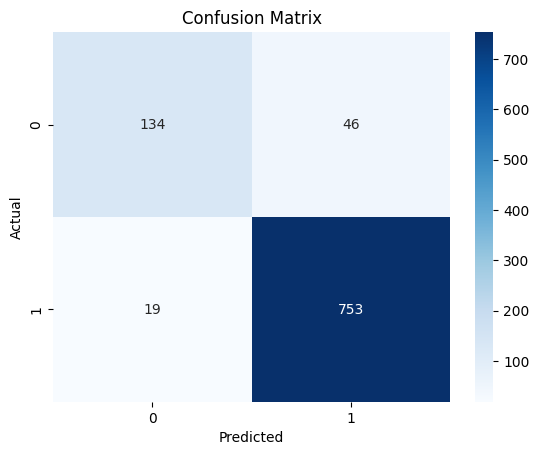

ROC Curve:


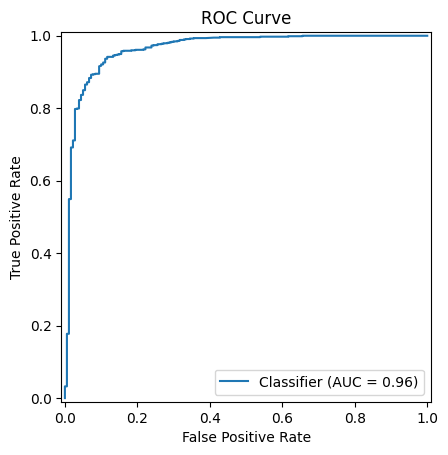

AUPRC Curve:


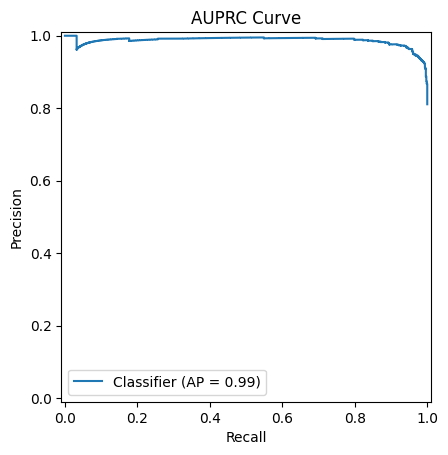

In [60]:
calc_metrics(final_model_cat)

In [ ]:
# Train loss on the full pool the model was trained on
calc_loss(final_model_cat)

from sklearn.metrics import log_loss
import numpy as np
train_ll = log_loss(y_train_full, final_model_cat.predict_proba(X_train_full))
print(f"Log Loss (Train+Val pool): {train_ll:.4f}")


In [ ]:
save_model(final_model_cat, best_params_cat, "catboost_bioactivity_model", model_path="catboost")

##### ExtraTree Classifier

In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings; warnings.filterwarnings("ignore")

N_CV_SPLITS = 3
N_TRIALS    = 20

def objective_et(trial, X_tr, y_tr, X_vf, y_vf):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight":      trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": RANDOM_STATE, "n_jobs": -1,
    }
    model = ExtraTreesClassifier(**params)
    model.fit(X_tr, y_tr)
    return roc_auc_score(y_vf, model.predict_proba(X_vf)[:, 1])

def objective_cv_et(trial):
    fold = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_cv_raw, y_cv)):
        score = objective_et(trial, X_cv_raw[tr_idx], y_cv[tr_idx],
                                    X_cv_raw[val_idx], y_cv[val_idx])
        scores.append(score)
        trial.report(np.mean(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

study_et = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study_et.optimize(objective_cv_et, n_trials=N_TRIALS, show_progress_bar=True)
print("Best params:", study_et.best_params)


In [ ]:
# ── Final ExtraTrees on full train+val with Optuna best params ──
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

best_params_et = study_et.best_params.copy()
best_params_et.update({"random_state": RANDOM_STATE, "n_jobs": -1})

X_train_full = np.vstack([X_train, X_val])
y_train_full  = np.concatenate([y_train, y_val])

final_model_et = ExtraTreesClassifier(**best_params_et)
final_model_et.fit(X_train_full, y_train_full)

print(f"Test Accuracy: {accuracy_score(y_test, final_model_et.predict(X_test)):.4f}")
print(classification_report(y_test, final_model_et.predict(X_test)))


In [ ]:
# ===========================================================================
# 10-Fold Stratified CV — ExtraTrees (Optuna Best Params)
# ===========================================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    average_precision_score, cohen_kappa_score, brier_score_loss,
)
import warnings; warnings.filterwarnings("ignore")

# X_cv_raw / y_cv: train+val pool (unscaled); X_test held out
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

METRIC_KEYS = [
    "Accuracy", "Balanced Acc", "Precision", "Recall",
    "F1", "ROC-AUC", "AUPRC", "MCC",
    "Sensitivity", "Specificity", "NPV", "Cohen s k", "Brier",
]
fold_metrics = {k: [] for k in METRIC_KEYS}

HDR = (f"{'Fold':>5}  {'Acc':>7}  {'Bal.Acc':>8}  {'Prec':>7}  {'Rec':>7}  "
       f"{'F1':>7}  {'AUC':>7}  {'AUPRC':>7}  {'MCC':>7}  {'Spec':>7}  "
       f"{'Kappa':>7}  {'Brier':>7}")
SEP = "=" * 100
print(SEP)
print("  10-Fold CV — ExtraTrees | Train+Val only (X_test held out)")
print(SEP); print(HDR); print("-" * 100)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cv_raw, y_cv), 1):
    X_tr, X_te = X_cv_raw[tr_idx].copy(), X_cv_raw[te_idx].copy()
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    model = ExtraTreesClassifier(**best_params_et)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    acc   = accuracy_score(y_te, y_pred)
    bacc  = balanced_accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)
    mcc   = matthews_corrcoef(y_te, y_pred)
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv   = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    kappa = cohen_kappa_score(y_te, y_pred, weights="quadratic")
    brier = brier_score_loss(y_te, y_prob)

    vals = [acc, bacc, prec, rec, f1, auc, auprc, mcc, sens, spec, npv, kappa, brier]
    for k, v in zip(METRIC_KEYS, vals):
        fold_metrics[k].append(v)

    print(f"  {fold:>3}  {acc:>7.4f}  {bacc:>8.4f}  {prec:>7.4f}  {rec:>7.4f}  "
          f"{f1:>7.4f}  {auc:>7.4f}  {auprc:>7.4f}  {mcc:>7.4f}  {spec:>7.4f}  "
          f"{kappa:>7.4f}  {brier:>7.4f}")

print(SEP)
print("\n  Per-Metric Summary\n")
rows = []
for k in METRIC_KEYS:
    arr = np.array(fold_metrics[k])
    rows.append({"Metric": k,
                  "Mean +- Std": f"{arr.mean():.4f} +- {arr.std():.4f}",
                  "Min": f"{arr.min():.4f}", "Max": f"{arr.max():.4f}",
                  "95% CI": f"[{arr.mean()-1.96*arr.std()/np.sqrt(N_SPLITS):.4f}, "
                             f"{arr.mean()+1.96*arr.std()/np.sqrt(N_SPLITS):.4f}]"})
print(pd.DataFrame(rows).set_index("Metric").to_string())

print("\n  Paper-Ready Summary\n")
paper_keys = ["Accuracy", "ROC-AUC", "F1", "MCC", "AUPRC", "Sensitivity", "Specificity", "Cohen s k", "Brier"]
paper_row  = {k: f"{np.mean(fold_metrics[k]):.4f} +- {np.std(fold_metrics[k]):.4f}" for k in paper_keys}
print(pd.DataFrame([paper_row], index=["ExtraTrees (10-Fold CV)"]).T.to_string())

et_cv_results = {k: np.array(v) for k, v in fold_metrics.items()}
print("\n[INFO] Results stored in et_cv_results")


Accuracy: 0.8666
Balanced Acc.: 0.8581
Cohen's Kappa: 0.6221
Precision: 0.9601
Recall: 0.8718
F1 Score: 0.9138
ROC-AUC: 0.9262
AUPRC: 0.9793
MCC: 0.6365
NPV: 0.6056
Specificity: 0.8444
Sensitivity: 0.8718
Informedness: 0.7162
DOR: 36.9033
Brier Score: 0.1044
********************
Confusion Matrix:


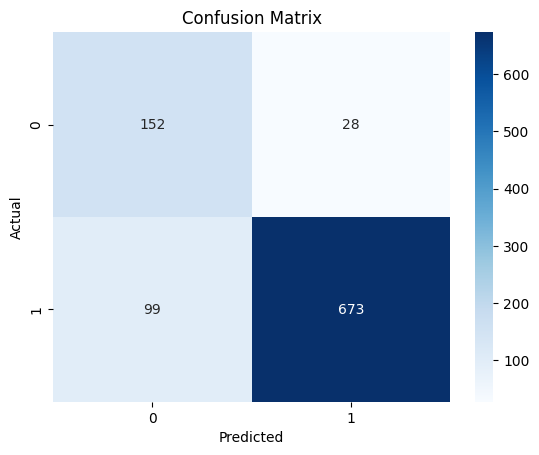

ROC Curve:


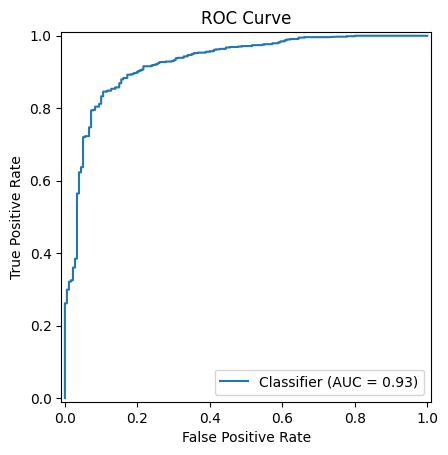

AUPRC Curve:


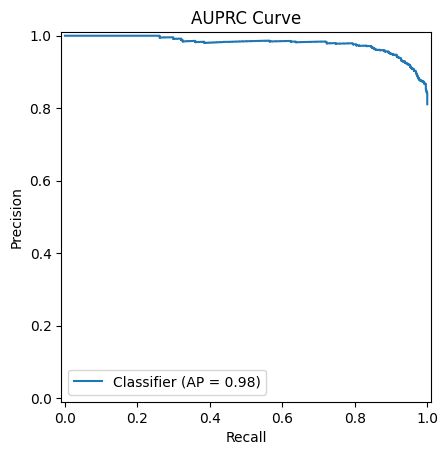

In [63]:
calc_metrics(final_model_et)

In [ ]:
# Train loss on the full pool the model was trained on
calc_loss(final_model_et)

from sklearn.metrics import log_loss
import numpy as np
train_ll = log_loss(y_train_full, final_model_et.predict_proba(X_train_full))
print(f"Log Loss (Train+Val pool): {train_ll:.4f}")


In [ ]:
save_model(final_model_et, best_params_et, "extratree_bioactivity_model", model_path="extratree")

#### CNN 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weights = torch.tensor([1.0, neg_count / pos_count], dtype=torch.float32).to(device)
print(f"Class imbalance ratio: {neg_count / pos_count:.2f}:1")

Class imbalance ratio: 0.24:1


In [18]:
class CNN1D(nn.Module):
    """
    1D CNN for tabular data classification
    """
    def __init__(self, input_size, trial):
        super(CNN1D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, log=True)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = 1
        current_size = input_size
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 32, 128, step=32)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 5, step=2)
            
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout_rate))
            
            # Optional pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool1d(pool_size))
                current_size = current_size // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_size
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 256, log=True)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, features) -> (batch, 1, features)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [19]:
class CNN2D(nn.Module):
    """
    2D CNN for image-like data classification
    Assumes input is reshaped to (batch, channels, height, width)
    """
    def __init__(self, input_channels, input_height, input_width, trial):
        super(CNN2D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 2, 5)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = input_channels
        current_h, current_w = input_height, input_width
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout2d(dropout_rate))
            
            # Pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool2d(pool_size))
                current_h = current_h // pool_size
                current_w = current_w // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_h * current_w
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 512, step=64)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [23]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [20]:
def objective_1d(trial):
    """
    Objective function for 1D CNN (for tabular data)
    """
    
    # Prepare data
    X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_tensor = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = 30
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    input_size = X_train_tensor.shape[1]
    model = CNN1D(input_size, trial).to(device)
    
    # Loss function with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    
    # Optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    use_scheduler = trial.suggest_categorical("use_scheduler", [True, False])
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    best_auc = 0
    patience_counter = 0
    early_stopping_patience = 10
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        y_true, y_pred, y_prob = evaluate(model, val_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step(train_loss)
        
        # Early stopping
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            break
        
        # Report to Optuna for pruning
        trial.report(auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_auc

##### 1d cnn

In [24]:
# Run optimization
import optuna
print("Starting CNN hyperparameter optimization...")
print("="*60)

# Choose which objective to use
study = optuna.create_study(
    direction="minimize",
    study_name="cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize (use objective_1d for tabular data, objective_2d for images)
study.optimize(objective_1d, n_trials=31, show_progress_bar=True)

# Print results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params

# Recreate best trial for model architecture
best_trial = study.best_trial

# Prepare data
X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
X_train_tensor = torch.FloatTensor(X_train_full)
y_train_tensor = torch.LongTensor(y_train_full)
X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create final model
input_size = X_train_tensor.shape[1]
final_model = CNN1D(input_size, best_trial).to(device)

# Train final model
criterion = nn.CrossEntropyLoss(weight=class_weights)

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_params['learning_rate'],  
                         weight_decay=best_params['weight_decay'])

for epoch in range(30):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {train_loss:.4f}")

# Final evaluation
y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))

# Save model
torch.save(final_model.state_dict(), 'best_cnn_model.pth')
print("\nModel saved as 'best_cnn_model.pth'")

[I 2025-11-21 09:05:26,148] A new study created in memory with name: cnn_optimization


Starting CNN hyperparameter optimization...


Best trial: 0. Best value: 0.921518:   3%|▎         | 1/31 [00:10<05:22, 10.76s/it]

[I 2025-11-21 09:05:36,904] Trial 0 finished with value: 0.9215184645966906 and parameters: {'batch_size': 64, 'learning_rate': 0.000291063591313307, 'weight_decay': 6.251373574521755e-05, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 2, 'dropout_rate': 0.31255143181676115, 'conv_0_out_channels': 32, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': True, 'conv_1_pool_size': 2, 'conv_2_out_channels': 96, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 120, 'fc_1_size': 190, 'use_scheduler': False}. Best is trial 0 with value: 0.9215184645966906.


Best trial: 1. Best value: 0.920731:   6%|▋         | 2/31 [00:24<05:57, 12.32s/it]

...

[I 2025-11-21 09:11:25,937] Trial 28 finished with value: 0.914179522356301 and parameters: {'batch_size': 64, 'learning_rate': 0.00010102955572424535, 'weight_decay': 0.0008432732955441743, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4996431941641488, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423:  97%|█████████▋| 30/31 [06:09<00:11, 11.06s/it]

[I 2025-11-21 09:11:35,524] Trial 29 finished with value: 0.9194011255144608 and parameters: {'batch_size': 64, 'learning_rate': 0.0001138953480076205, 'weight_decay': 0.000850088685083961, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.48164086960695207, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 112, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423: 100%|██████████| 31/31 [06:18<00:00, 12.22s/it]



[I 2025-11-21 09:11:45,081] Trial 30 finished with value: 0.9192681356216926 and parameters: {'batch_size': 64, 'learning_rate': 8.038437951279324e-05, 'weight_decay': 0.0009898963513775172, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4019959147176979, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.

OPTIMIZATION RESULTS
Best trial: 26
Best AUC: 0.1026

Best hyperparameters:
  batch_size: 64
  learning_rate: 9.154974422549072e-05
  weight_decay: 3.974413799446102e-05
  optimizer: Adam
  n_conv_layers: 3
  n_fc_layers: 1
  dropout_rate: 0.38153498503932975
  conv_0_out_channels: 64
  conv_0_kernel_size: 3
  conv_0_pooling: True
  conv_0_pool_size: 3
  conv_1_out

Accuracy: 0.8519
Balanced Acc.: 0.6190
Precision: 0.8494
Recall: 0.9935
F1 Score: 0.9158
ROC-AUC: 0.9205
MCC: 0.4217
NPV: 0.8980
AUPRC: 0.9753
Specificity: 0.2444
Sensitivity: 0.9935
Informedness: 0.2380
DOR: 49.6294
Brier Score: 0.1129
********************
Confusion Matrix:


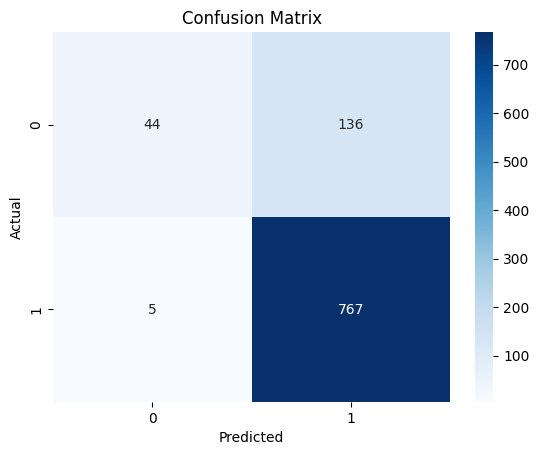

ROC Curve:


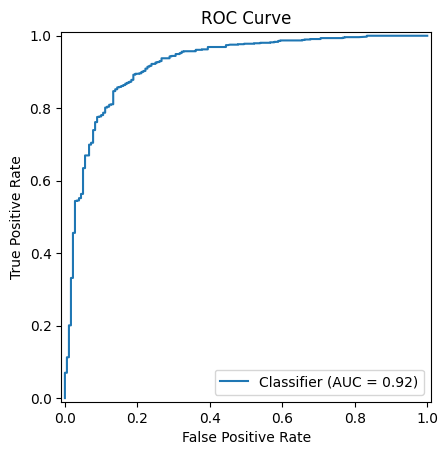

AUPRC Curve:


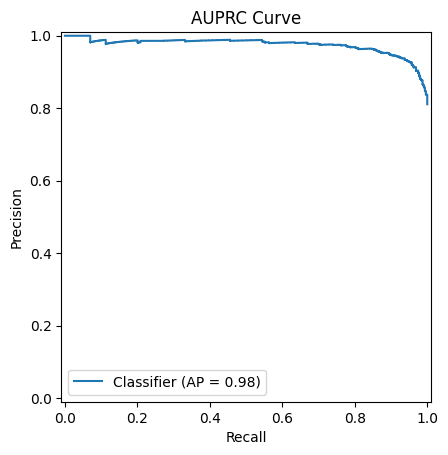

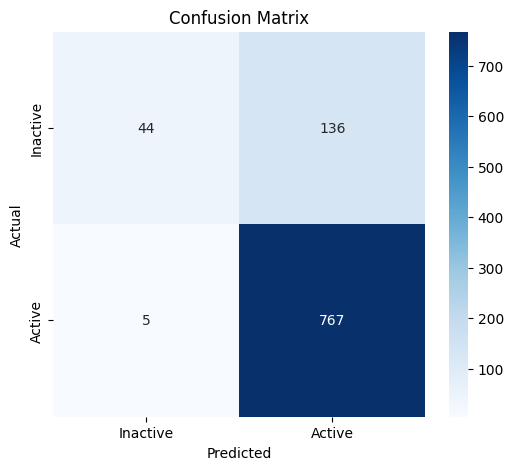

              precision    recall  f1-score   support

           0       0.90      0.24      0.38       180
           1       0.85      0.99      0.92       772

    accuracy                           0.85       952
   macro avg       0.87      0.62      0.65       952
weighted avg       0.86      0.85      0.82       952



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
import matplotlib.pyplot as plt

# Get predictions and true labels
if hasattr(final_model, "predict") and 'X_test' in globals():
    y_pred_local = final_model.predict(X_test)
    y_true_local = y_test.values if hasattr(y_test, "values") else y_test
elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
    y_pred_local = y_pred
    y_true_local = y_true
    y_prob_local = y_prob
else:
    # Fall back to using the PyTorch model and test_loader
    final_model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            out = final_model(bx)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            prob = torch.softmax(out, dim=1)[:, 1]
            preds.append(pred)
            trues.append(by.numpy())
            probs.append(prob)
    y_pred_local = np.concatenate(preds)
    y_true_local = np.concatenate(trues)
    y_prob_local = np.concatenate(probs)
# Plot
accuracy = accuracy_score(y_true_local, y_pred_local)
balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
precision = precision_score(y_true_local, y_pred_local)
recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
f1 = f1_score(y_true_local, y_pred_local)
roc_auc = roc_auc_score(y_true_local, y_prob_local)
mcc = matthews_corrcoef(y_true_local, y_pred_local)
auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve
kappa = cohen_kappa_score(y_true_local, y_pred_local, weights='quadratic')

# For Specificity: Derive from confusion matrix
cm = confusion_matrix(y_true_local, y_pred_local)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) 
sensitivity = recall  # Same as recall
informedness = sensitivity + specificity - 1

dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

brier = brier_score_loss(y_true_local, y_prob_local)

# Step 3: Print or store results (e.g., to fill your table)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"NPV: {npv:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print("Informedness: {:.4f}".format(informedness))
print(f"DOR: {dor:.4f}")
print(f"Brier Score: {brier:.4f}")

print("********************")
print("Confusion Matrix:")
plot_confusion_matrix(y_true_local, y_pred_local)

print("ROC Curve:")
plot_roc_curve(y_true_local, y_prob_local)

print("AUPRC Curve:")
plot_auprc_curve(y_true_local, y_prob_local)

cm = confusion_matrix(y_true_local, y_pred_local)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true_local, y_pred_local))

##### 2d

In [ ]:
# # Run optimization
# print("Starting CNN hyperparameter optimization...")
# print("="*60)

# # Choose which objective to use
# study = optuna.create_study(
#     direction="minimize",
#     study_name="cnn_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# # Optimize (use objective_1d for tabular data, objective_2d for images)
# study.optimize(objective_2d, n_trials=50, show_progress_bar=True)

# # Print results
# print("\n" + "="*60)
# print("OPTIMIZATION RESULTS")
# print("="*60)
# print(f"Best trial: {study.best_trial.number}")
# print(f"Best AUC: {1 - study.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

# # Train final model with best parameters
# print("\n" + "="*60)
# print("TRAINING FINAL MODEL")
# print("="*60)

# best_params = study.best_params

# # Recreate best trial for model architecture
# best_trial = study.best_trial

# # Prepare data
# X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
# y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
# X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
# y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size = best_params['batch_size']
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Create final model
# input_size = X_train_tensor.shape[1]
# final_model = CNN1D(input_size, best_trial).to(device)

# # Train final model
# criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

# if best_params['optimizer'] == "Adam":
#     optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
#                           weight_decay=best_params['weight_decay'])
# elif best_params['optimizer'] == "AdamW":
#     optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
#                            weight_decay=best_params['weight_decay'])
# else:
#     optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
#                          momentum=best_params.get('momentum', 0.9), 
#                          weight_decay=best_params['weight_decay'])

# for epoch in range(best_params['n_epochs']):
#     train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# # Final evaluation
# y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

# print(f"\nFinal Model Performance:")
# print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
# print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

# from sklearn.metrics import classification_report, confusion_matrix
# print(f"\nConfusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print(f"\nClassification Report:")
# print(classification_report(y_true, y_pred))

# # Save model
# torch.save(final_model.state_dict(), 'best_cnn_model_2d.pth')
# print("\nModel saved as 'best_cnn_model_2d.pth'")

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
# import matplotlib.pyplot as plt

# # Get predictions and true labels
# if hasattr(final_model, "predict") and 'X_test' in globals():
#     y_pred_local = final_model.predict(X_test)
#     y_true_local = y_test.values if hasattr(y_test, "values") else y_test
# elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
#     y_pred_local = y_pred
#     y_true_local = y_true
#     y_prob_local = y_prob
# else:
#     # Fall back to using the PyTorch model and test_loader
#     final_model.eval()
#     preds, trues, probs = [], [], []
#     with torch.no_grad():
#         for bx, by in test_loader:
#             bx = bx.to(device)
#             out = final_model(bx)
#             pred = torch.argmax(out, dim=1).cpu().numpy()
#             prob = torch.softmax(out, dim=1)[:, 1]
#             preds.append(pred)
#             trues.append(by.numpy())
#             probs.append(prob)
#     y_pred_local = np.concatenate(preds)
#     y_true_local = np.concatenate(trues)
#     y_prob_local = np.concatenate(probs)
# # Plot
# accuracy = accuracy_score(y_true_local, y_pred_local)
# balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
# precision = precision_score(y_true_local, y_pred_local)
# recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
# f1 = f1_score(y_true_local, y_pred_local)
# roc_auc = roc_auc_score(y_true_local, y_prob_local)
# mcc = matthews_corrcoef(y_true_local, y_pred_local)
# auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# # For Specificity: Derive from confusion matrix
# cm = confusion_matrix(y_true_local, y_pred_local)
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
# sensitivity = recall  # Same as recall

# # Step 3: Print or store results (e.g., to fill your table)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Balanced Acc.: {balanced_acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"MCC: {mcc:.4f}")
# print(f"Specificity: {specificity:.4f}")
# print(f"Sensitivity: {sensitivity:.4f}")
# print(f"AUPRC: {auprc:.4f}")
# cm = confusion_matrix(y_true_local, y_pred_local)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# # Print classification report
# print(classification_report(y_true_local, y_pred_local))

 #### SVN 

In [38]:
import optuna
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# SVM (Support Vector Machine) Optimization
# ============================================================================

print("="*70)
print("SVM HYPERPARAMETER OPTIMIZATION")
print("="*70)



# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_svm(trial):
    param = {
        # Kernel type
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
        
        # Regularization parameter
        "C": trial.suggest_float("C", 1e-3, 1e-2, log=True),
        
        # Kernel coefficient (for rbf, poly, sigmoid)
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        
        # Degree for polynomial kernel
        "degree": trial.suggest_int("degree", 2, 5) if trial.params.get("kernel") == "poly" else 3,
        
        # Class weight for imbalance
        "class_weight": trial.suggest_categorical("class_weight", ["balanced"]),
        
        # Probability estimates (needed for ROC-AUC)
        "probability": True,
        
        # Tolerance for stopping criterion
        "tol": trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        
        # Maximum iterations
        "max_iter": trial.suggest_int("max_iter", 100, 1000, step=100),
        
        # Shrinking heuristic
        "shrinking": trial.suggest_categorical("shrinking", [True, False])
    }
    
    # Remove degree if not polynomial kernel
    if param["kernel"] != "poly":
        param.pop("degree", None)
    
    model = SVC(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return auc  # Optuna minimizes, so invert AUC

# Create and run study
study_svm = optuna.create_study(
    direction="maximize",
    study_name="svm_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting SVM optimization...")
study_svm.optimize(objective_svm, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("SVM OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_svm.best_trial.number}")
print(f"Best AUC: {1 - study_svm.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_svm.best_params.items():
    print(f"  {key}: {value}")

# Train final SVM model with best params
print("\n" + "="*70)
print("TRAINING FINAL SVM MODEL")
print("="*70)

best_params_svm = study_svm.best_params.copy()
best_params_svm.update({
    "probability": True,
    "random_state": 42
})

final_model_svm = SVC(**best_params_svm)
final_model_svm.fit(X_train_full, y_train_full)

# Evaluate on test set
y_pred_svm = final_model_svm.predict(X_test)
y_pred_proba_svm = final_model_svm.predict_proba(X_test)[:, 1]

print(f"\nFinal SVM Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

[I 2025-11-21 09:52:26,531] A new study created in memory with name: svm_optimization


SVM HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.24:1

Starting SVM optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=700).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 0. Best value: 0.589838:   3%|▎         | 1/31 [00:10<05:01, 10.04s/it]

[I 2025-11-21 09:52:36,574] Trial 0 finished with value: 0.5898381722989052 and parameters: {'kernel': 'rbf', 'C': 0.001432249371823025, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.003967605077052989, 'max_iter': 700, 'shrinking': True}. Best is trial 0 with value: 0.5898381722989052.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=300).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 1. Best value: 0.797722:   6%|▋         | 2/31 [00:15<03:26,  7.10s/it]

...

[I 2025-11-21 09:57:23,997] Trial 29 finished with value: 0.5892432175154688 and parameters: {'kernel': 'rbf', 'C': 0.0030713990506156742, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.0051463646467119414, 'max_iter': 700, 'shrinking': False}. Best is trial 13 with value: 0.922942856342918.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 13. Best value: 0.922943: 100%|██████████| 31/31 [05:09<00:00,  9.98s/it]


[I 2025-11-21 09:57:36,011] Trial 30 finished with value: 0.9187431755186607 and parameters: {'kernel': 'linear', 'C': 0.002597055152470495, 'gamma': 'auto', 'class_weight': 'balanced', 'tol': 0.003481899701354786, 'max_iter': 1000, 'shrinking': False}. Best is trial 13 with value: 0.922942856342918.

SVM OPTIMIZATION RESULTS
Best trial: 13
Best AUC: 0.0771

Best hyperparameters:
  kernel: linear
  C: 0.002441148527158019
  gamma: auto
  class_weight: balanced
  tol: 0.0007262151024232333
  max_iter: 900
  shrinking: False

TRAINING FINAL SVM MODEL


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Final SVM Model Performance:
  Accuracy: 0.8634
  ROC-AUC: 0.9169

Confusion Matrix:
[[155  25]
 [105 667]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.86      0.70       180
           1       0.96      0.86      0.91       772

    accuracy                           0.86       952
   macro avg       0.78      0.86      0.81       952
weighted avg       0.89      0.86      0.87       952



Accuracy: 0.8634
Balanced Acc.: 0.8626
Cohen's Kappa: 0.6195
Precision: 0.9639
Recall: 0.8640
F1 Score: 0.9112
ROC-AUC: 0.9169
AUPRC: 0.9718
MCC: 0.6372
NPV: 0.5962
Specificity: 0.8611
Sensitivity: 0.8640
Informedness: 0.7251
DOR: 39.3848
Brier Score: 0.0764
********************
Confusion Matrix:


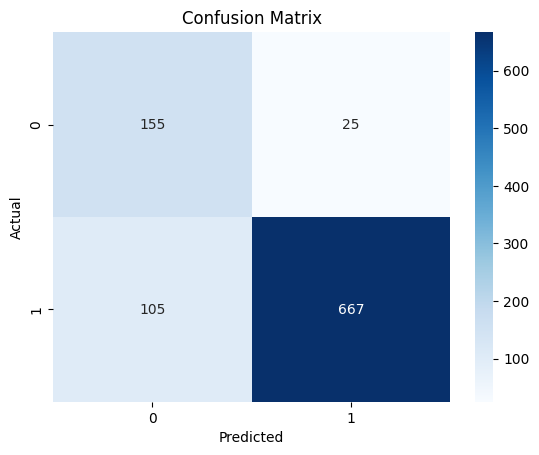

ROC Curve:


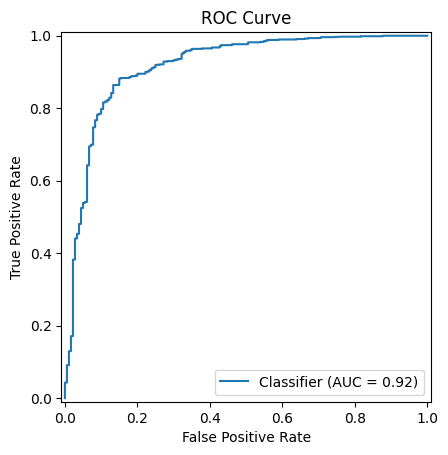

AUPRC Curve:


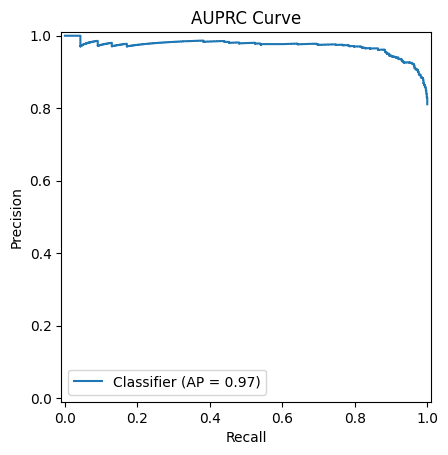

In [39]:
calc_metrics(final_model_svm)

In [40]:
save_model(final_model_svm, best_params_svm, "svm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


In [ ]:
shap_plot(final_model_svm)

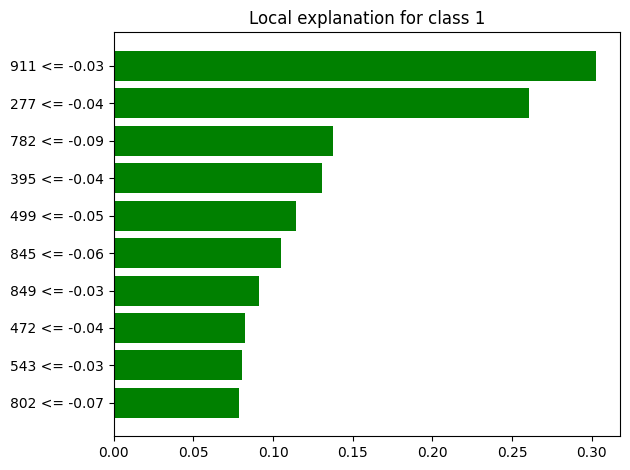


Feature contributions:
[('911 <= -0.03', 0.3026447902186193), ('277 <= -0.04', 0.26048903949675317), ('782 <= -0.09', 0.13735240368978446), ('395 <= -0.04', 0.1304591724730728), ('499 <= -0.05', 0.11412449744423452), ('845 <= -0.06', 0.10488271948580676), ('849 <= -0.03', 0.09087758974343749), ('472 <= -0.04', 0.08209143437356617), ('543 <= -0.03', 0.08069554994149634), ('802 <= -0.07', 0.07887232874890782)]

Explanation as dict:
{1: [(911, 0.3026447902186193), (277, 0.26048903949675317), (782, 0.13735240368978446), (395, 0.1304591724730728), (499, 0.11412449744423452), (845, 0.10488271948580676), (849, 0.09087758974343749), (472, 0.08209143437356617), (543, 0.08069554994149634), (802, 0.07887232874890782)]}


In [ ]:
lime_plot(final_model_svm)

#### KNN 

In [44]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# KNN (K-Nearest Neighbors) Optimization
# ============================================================================

print("="*70)
print("KNN HYPERPARAMETER OPTIMIZATION")
print("="*70)


# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_knn(trial):
    param = {
        # Number of neighbors
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 20, step=5),
        
        # Distance metric
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        
        # Power parameter for Minkowski distance
        "p": trial.suggest_int("p", 1, 3) if trial.params.get("metric") == "minkowski" else 2,
        
        # Weight function
        "weights": trial.suggest_categorical("weights", ["distance"]),
        
        # Algorithm to compute nearest neighbors
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
        
        # Leaf size for ball_tree or kd_tree
        "leaf_size": trial.suggest_int("leaf_size", 10, 20, step=5),

        "n_jobs": -1
    }
    
    # Remove p if not minkowski metric
    if param["metric"] != "minkowski":
        param.pop("p", None)
    
    model = KNeighborsClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC (using predict_proba)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return auc  # Optuna minimizes, so invert AUC

# Create and run study
study_knn = optuna.create_study(
    direction="maximize",
    study_name="knn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting KNN optimization...")
study_knn.optimize(objective_knn, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("KNN OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_knn.best_trial.number}")
print(f"Best AUC: {1 - study_knn.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")

# Train final KNN model with best params
print("\n" + "="*70)
print("TRAINING FINAL KNN MODEL")
print("="*70)

best_params_knn = study_knn.best_params.copy()


final_model_knn = KNeighborsClassifier(**best_params_knn)
final_model_knn.fit(X_train_full, y_train_full)

# Evaluate on test set
y_pred_knn = final_model_knn.predict(X_test)
y_pred_proba_knn = final_model_knn.predict_proba(X_test)[:, 1]

print(f"\nFinal KNN Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

[I 2025-11-21 10:17:59,678] A new study created in memory with name: knn_optimization


KNN HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.24:1

Starting KNN optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 0. Best value: 0.900321:   3%|▎         | 1/31 [00:00<00:04,  6.63it/s]

[I 2025-11-21 10:17:59,828] Trial 0 finished with value: 0.9003205756362516 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 0 with value: 0.9003205756362516.


e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 1. Best value: 0.915688:   6%|▋         | 2/31 [00:00<00:06,  4.26it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(


...

[I 2025-11-21 10:18:16,632] Trial 27 finished with value: 0.9156879077190133 and parameters: {'n_neighbors': 13, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 10}. Best is trial 1 with value: 0.9156879077190133.


Best trial: 1. Best value: 0.915688:  94%|█████████▎| 29/31 [00:17<00:01,  1.65it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 1. Best value: 0.915688:  97%|█████████▋| 30/31 [00:17<00:00,  2.15it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(


[I 2025-11-21 10:18:17,436] Trial 28 finished with value: 0.9009575272279307 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 15}. Best is trial 1 with value: 0.9156879077190133.
[I 2025-11-21 10:18:17,570] Trial 29 finished with value: 0.8872665677408518 and parameters: {'n_neighbors': 3, 'metric': 'minkowski', 'p': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 1 with value: 0.9156879077190133.


Best trial: 1. Best value: 0.915688: 100%|██████████| 31/31 [00:18<00:00,  1.72it/s]


[I 2025-11-21 10:18:17,705] Trial 30 finished with value: 0.8930341294061652 and parameters: {'n_neighbors': 18, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 10}. Best is trial 1 with value: 0.9156879077190133.

KNN OPTIMIZATION RESULTS
Best trial: 1
Best AUC: 0.0843

Best hyperparameters:
  n_neighbors: 13
  metric: manhattan
  weights: distance
  algorithm: brute
  leaf_size: 15

TRAINING FINAL KNN MODEL

Final KNN Model Performance:
  Accuracy: 0.9191
  ROC-AUC: 0.9358

Confusion Matrix:
[[126  54]
 [ 23 749]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       180
           1       0.93      0.97      0.95       772

    accuracy                           0.92       952
   macro avg       0.89      0.84      0.86       952
weighted avg       0.92      0.92      0.92       952



Accuracy: 0.9191
Balanced Acc.: 0.8351
Cohen's Kappa: 0.7176
Precision: 0.9328
Recall: 0.9702
F1 Score: 0.9511
ROC-AUC: 0.9358
AUPRC: 0.9767
MCC: 0.7223
NPV: 0.8456
Specificity: 0.7000
Sensitivity: 0.9702
Informedness: 0.6702
DOR: 75.9855
Brier Score: 0.0634
********************
Confusion Matrix:


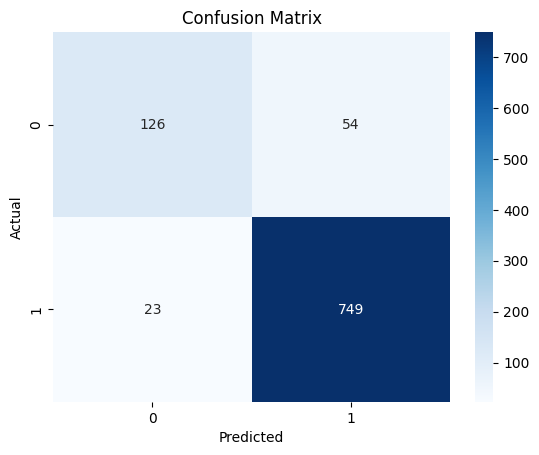

ROC Curve:


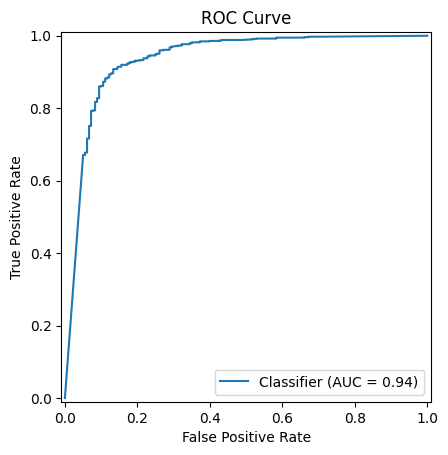

AUPRC Curve:


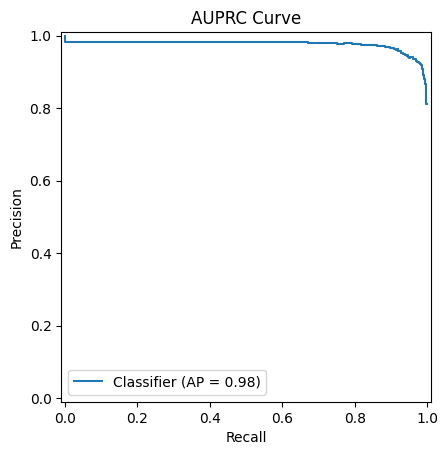

In [45]:
calc_metrics(final_model_knn)

In [ ]:
calc_loss(final_model_knn)

Log Loss(Test): 0.7723670602184197
Log Loss(Train): 0.011758831433212297
Log Loss(Train): 0.011758831433212297
Focal Loss (Test Set): 0.0959
Focal Loss (Test Set): 0.0959


In [ ]:
lime_plot(final_model_knn)

In [46]:
save_model(final_model_knn, best_params_knn, "knn_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


#### Ensembles

##### Voting 

In [52]:
import joblib

# Replace with your actual model name
model_name = "xgboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_xgb = joblib.load(model_path)


# Replace with your actual model name
model_name = "random_forest_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_rf = joblib.load(model_path)



# Replace with your actual model name
model_name = "lightgbm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_lgbm = joblib.load(model_path)



# Replace with your actual model name
model_name = "catboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_cat = joblib.load(model_path)



# Replace with your actual model name
model_name = "svm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_svm = joblib.load(model_path)


# Replace with your actual model name
model_name = "extratree_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_et = joblib.load(model_path)

In [53]:
import optuna
from sklearn.ensemble import (
    VotingClassifier, 
    StackingClassifier, 
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np



# ============================================================================
# 1. VOTING CLASSIFIER (Soft Voting)
# ============================================================================

print("="*70)
print("VOTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_voting(trial):
    """
    Voting Classifier with multiple base estimators

    NOTE: to avoid multiprocessing / pickling issues (BrokenProcessPool),
    force single-threaded / no-process parallelism for estimators and the
    VotingClassifier (n_jobs=1). Also enable probability=True for SVC so
    soft voting can use predict_proba.
    """
    
    # Define base estimators with their hyperparameters
    
    # XGBoost
    # xgb_params = {
    #     'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'eval_metric': 'auc',
    #     'n_jobs': 1
    # }
    
    # # LightGBM
    # lgbm_params = {
    #     'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'verbosity': -1,
    #     'n_jobs': 1
    # }
    
    # # Random Forest (via sklearn)
    # from sklearn.ensemble import RandomForestClassifier
    # rf_params = {
    #     'n_estimators': trial.suggest_int('rf_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('rf_max_depth', 3, 20),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'n_jobs': 1
    # }

    # # Support Vector (enable probability for soft voting)
    # sf_params={
    #     'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    #     'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
    #     'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
    #     'class_weight': 'balanced',
    #     'probability': True,
    #     'random_state': 42
    # }

    
    # # Logistic Regression
    # lr_params = {
    #     'C': trial.suggest_float('lr_C', 0.01, 10, log=True),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'max_iter': 1000,
    #     'n_jobs': 1
    # }
    
    # Create base estimators
    estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # Voting type
    voting = trial.suggest_categorical('voting', ['soft', 'hard'])
    
    # Weights for each estimator (if soft voting)
    if voting == 'soft':
        weights = [
            trial.suggest_float(f'weight_{name}', 0.5, 2.0)
            for name in ['xgb', 'lgbm', 'rf', 'cat', 'sf', 'ext']
        ]
    else:
        weights = None
    
    # Create voting classifier
    # Set n_jobs=1 to avoid nested multiprocessing / pickling issues
    voting_model = VotingClassifier(
        estimators=estimators,
        voting=voting,
        weights=weights,
        n_jobs=1
    )
    
    voting_model.fit(X_train, y_train)
    
    if voting == 'soft':
        preds_proba = voting_model.predict_proba(X_val)[:, 1]
    else:
        # For hard voting, use predicted labels and return 1 - accuracy (same as before)
        preds = voting_model.predict(X_val)
        auc = roc_auc_score(y_val, preds)
        return auc
    
    auc = roc_auc_score(y_val, preds_proba)
    return auc

study_voting = optuna.create_study(
    direction="maximize",
    study_name="voting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

print("Starting Voting Classifier optimization...")
study_voting.optimize(objective_voting, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("VOTING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {study_voting.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_voting.best_params.items():
    print(f"  {key}: {value}")


[I 2025-11-21 10:30:09,754] A new study created in memory with name: voting_optimization


VOTING CLASSIFIER OPTIMIZATION
Starting Voting Classifier optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.857204:   3%|▎         | 1/31 [00:19<09:49, 19.63s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  

[I 2025-11-21 10:30:29,387] Trial 0 finished with value: 0.8572038525072097 and parameters: {'voting': 'hard'}. Best is trial 0 with value: 0.8572038525072097.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 1. Best value: 0.960439:   6%|▋         | 2/31 [00:39<09:38, 19.95s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-11-21 10:39:57,413] Trial 28 finished with value: 0.9640927289525996 and parameters: {'voting': 'soft', 'weight_xgb': 1.3504518016948448, 'weight_lgbm': 1.8922196881882951, 'weight_rf': 1.9566561651881624, 'weight_cat': 1.460795200048445, 'weight_sf': 1.6591619083276954, 'weight_ext': 0.8874175814361605}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492:  97%|█████████▋| 30/31 [10:09<00:20, 20.93s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:40:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-11-21 10:40:19,032] Trial 29 finished with value: 0.8512018086625416 and parameters: {'voting': 'hard'}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492: 100%|██████████| 31/31 [10:30<00:00, 20.32s/it]

[I 2025-11-21 10:40:39,776] Trial 30 finished with value: 0.9625738443878266 and parameters: {'voting': 'soft', 'weight_xgb': 1.587742324549121, 'weight_lgbm': 1.38802921792744, 'weight_rf': 1.8017742260283671, 'weight_cat': 1.0809080624044292, 'weight_sf': 1.7891664701022467, 'weight_ext': 1.1761826289325492}. Best is trial 27 with value: 0.9644916986309041.

VOTING CLASSIFIER RESULTS
Best AUC: 0.9645

Best hyperparameters:
  voting: soft
  weight_xgb: 1.2596072216604863
  weight_lgbm: 1.8015243158548453
  weight_rf: 1.997909627607913
  weight_cat: 1.0766023113224443
  weight_sf: 1.4934874656915478
  weight_ext: 0.8358873684991758


In [56]:
estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]

best_weights = [
    1.2596072216604863,  # weight_xgb
    1.8015243158548453,  # weight_lgbm
    1.997909627607913,  # weight_rf
    1.0766023113224443,  # weight_cat
    1.4934874656915478,  # weight_sf
    0.8358873684991758   # weight_ext
]

# Create the VotingClassifier with the best parameters
voting_model = VotingClassifier(
    estimators=estimators,
    voting='soft',  # Best voting type from Optuna
    weights=best_weights,  # Best weights from Optuna
    n_jobs=1  # Avoid multiprocessing issues
)

# Fit the VotingClassifier (uses pre-trained models without retraining)
voting_model.fit(X_train_full, y_train_full)

# Predict on the validation and test sets

y_test_pred = voting_model.predict(X_test)
y_test_pred_proba = voting_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Detailed classification report for validation set
test_report = classification_report(y_test, y_test_pred)
print("classification_report")
print(test_report)

e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:46:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


classification_report
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       180
           1       0.94      0.98      0.96       772

    accuracy                           0.94       952
   macro avg       0.93      0.86      0.89       952
weighted avg       0.94      0.94      0.94       952



e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9380
Balanced Acc.: 0.8638
Cohen's Kappa: 0.7826
Precision: 0.9429
Recall: 0.9832
F1 Score: 0.9626
ROC-AUC: 0.9641
AUPRC: 0.9886
MCC: 0.7885
NPV: 0.9116
Specificity: 0.7444
Sensitivity: 0.9832
Informedness: 0.7276
DOR: 170.0769
Brier Score: 0.0518
********************
Confusion Matrix:


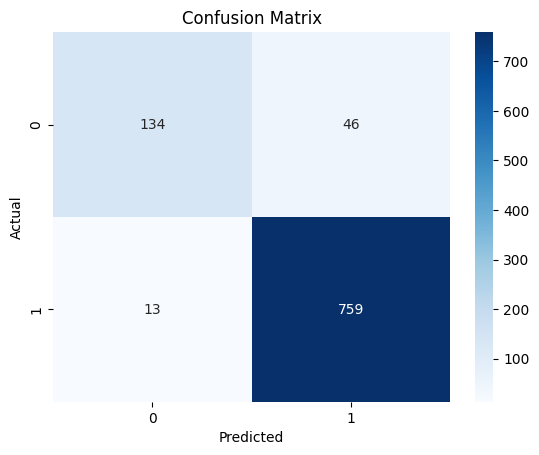

ROC Curve:


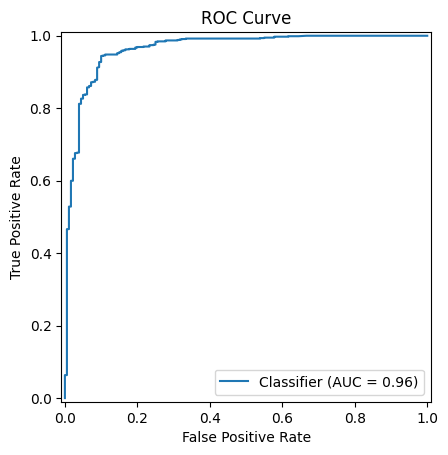

AUPRC Curve:


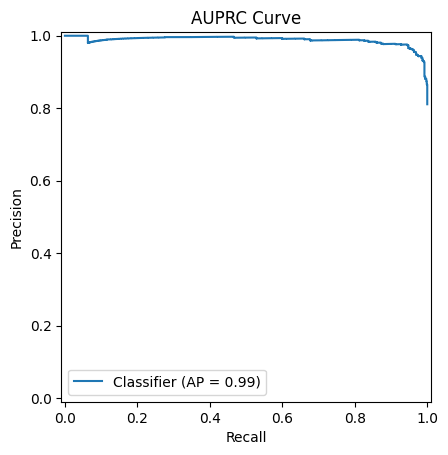

In [58]:
calc_metrics(voting_model)

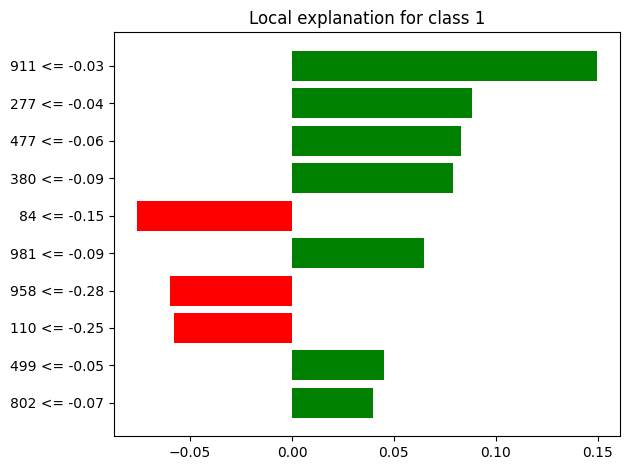


Feature contributions:
[('911 <= -0.03', 0.1496308227435044), ('277 <= -0.04', 0.08820697631825977), ('477 <= -0.06', 0.08290040697853725), ('380 <= -0.09', 0.07897755564758215), ('84 <= -0.15', -0.07602296436455713), ('981 <= -0.09', 0.06474482480789492), ('958 <= -0.28', -0.0600420255951942), ('110 <= -0.25', -0.05765289937634996), ('499 <= -0.05', 0.04509903934089284), ('802 <= -0.07', 0.03953451151167671)]

Explanation as dict:
{1: [(np.int64(911), np.float64(0.1496308227435044)), (np.int64(277), np.float64(0.08820697631825977)), (np.int64(477), np.float64(0.08290040697853725)), (np.int64(380), np.float64(0.07897755564758215)), (np.int64(84), np.float64(-0.07602296436455713)), (np.int64(981), np.float64(0.06474482480789492)), (np.int64(958), np.float64(-0.0600420255951942)), (np.int64(110), np.float64(-0.05765289937634996)), (np.int64(499), np.float64(0.04509903934089284)), (np.int64(802), np.float64(0.03953451151167671))]}


In [ ]:
lime_plot(voting_model)

In [59]:
save_model(voting_model, study_voting.best_params, "voting_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


<!-- ##### Stacking -->

In [ ]:
# import joblib
# model_ = joblib.load("saved_model/ml_models/lightgbm_bioactivity_model.pkl")

In [74]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import os

# ============================================================================
# HYBRID APPROACH: Speed + Accuracy Balance
# ============================================================================

def objective_stacking_balanced(trial):
    """
    BALANCED VERSION: Good speed (5-8 min/trial) + High accuracy
    
    Speed optimizations:
    - Fixed CV=3 (vs 3-5)
    - Moderate n_jobs=2
    - Reduced but comprehensive search space
    
    Accuracy maintained:
    - All 5 meta-learner types (LR, XGB, LGBM, Cat, SVM)
    - Key hyperparameters still tuned
    - Passthrough still optimized
    """
    
    base_estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # All meta-learners included for accuracy
    meta_learner_type = trial.suggest_categorical('meta_learner', ['lr', 'ridge', 'ridge_cv'])
    
    if meta_learner_type == 'lr':
        # Simplified but still effective
        meta_penalty = trial.suggest_categorical('meta_penalty', ['l2', 'l1', 'elasticnet'])
         
        meta_solver = trial.suggest_categorical('meta_solver', ['lbfgs', 'saga'])
        
        if meta_penalty == 'l2' and meta_solver not in ['lbfgs', 'saga']:
            raise optuna.TrialPruned()
        if meta_penalty in ['l1', 'elasticnet'] and meta_solver != 'saga':
            raise optuna.TrialPruned()
        
        params = {
            'C': trial.suggest_float('meta_C', 0.01, 10, log=True),
            'class_weight': trial.suggest_categorical('meta_class_weight', ['balanced']),
            'random_state': 42,
            'max_iter': 1000,  # Fixed for speed
            'solver': meta_solver,
            'penalty': meta_penalty,
            'tol': 1e-4 # Fixed for speed
        }
        if meta_penalty == 'elasticnet':
            params['l1_ratio'] = trial.suggest_float('meta_l1_ratio', 0.0, 1.0)
        
        meta_learner = LogisticRegression(**params)
    
    elif meta_learner_type == 'ridge':
        meta_learner = RidgeClassifier(
            alpha=trial.suggest_float('meta_alpha', 1e-3, 10.0, log=True),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            max_iter=1000,
            tol=1e-4
        )
    else:
        meta_learner = RidgeClassifierCV(
            alphas=np.logspace(-3, 3, 10),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            cv=3
        )   
    
    
    # Moderate n_jobs=2 (faster than 1, safer than -1)
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        passthrough=trial.suggest_categorical('passthrough', [True, False])  # Keep for accuracy
    )
    
    try:
        model.fit(X_train, y_train)
        # Only call predict_proba if supported
        if hasattr(model, "predict_proba"):
            preds_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, preds_proba)
        else:
            preds = model.predict(X_val)
            auc = roc_auc_score(y_val, preds)
        return auc
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0



# ============================================================================
# EXECUTION: Choose Your Strategy
# ============================================================================

os.environ['OPTUNA_DISABLE_FORK'] = '1'

print("\n" + "="*80)
print("STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED")
print("="*80)

# ============================================================================
# OPTION 1: BALANCED (Recommended - Good for most cases)
# Time: ~5-8 min/trial, 30 trials = 2.5-4 hours
# Accuracy: High (all meta-learners, key params tuned)
# ============================================================================

print("\n[OPTION 1: BALANCED APPROACH]")
print("Expected accuracy: High (comprehensive search)")

study_balanced = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

study_balanced.optimize(objective_stacking_balanced, n_trials=31, show_progress_bar=True)

print(f"\n✓ Best AUC: {study_balanced.best_value:.4f}")
print(f"Best meta-learner: {study_balanced.best_params['meta_learner']}")


# ============================================================================
# RESULTS AND FINAL MODEL
# ============================================================================

study_final = study_balanced  # or study_stage2 if using two-stage

print("\n" + "="*80)
print("OPTIMIZATION RESULTS")
print("="*80)
print(f"Best Validation AUC: {1 - study_final.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-21 22:52:22,454] A new study created in memory with name: no-name-9a020033-3e35-4fca-9a63-611ec73c81fc



STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED

[OPTION 1: BALANCED APPROACH]
Expected accuracy: High (comprehensive search)


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, 

[I 2025-11-21 22:54:31,470] Trial 0 finished with value: 0.8610920570036678 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.24810409748678125, 'meta_class_weight': 'balanced', 'passthrough': True}. Best is trial 0 with value: 0.8610920570036678.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

...

[I 2025-11-21 23:52:57,522] Trial 28 finished with value: 0.8815480023518214 and parameters: {'meta_learner': 'ridge_cv', 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:55:10,244] Trial 29 finished with value: 0.8715632611921493 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.0016462494656141725, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:57:23,980] Trial 30 finished with value: 0.8675245681328219 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 9.777198713756135, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.

✓ Best AUC: 0.9640
Best meta-learner: lr

OPTIMIZATION RESULTS
Best Validation AUC: 0.0360

Best Parameters:
  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [75]:
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [76]:
import pickle

# Save to pickle (after optimization)
with open("study_stacking.pkl", "wb") as f:
    pickle.dump(study_final, f)
print("Study saved to study_stacking.pkl")



Study saved to study_stacking.pkl


In [ ]:
# study_final

e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:49:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi


Final Stacking Model Performance:
  Accuracy: 0.9265
  ROC-AUC: 0.9573

Confusion Matrix:
[[156  24]
 [ 46 726]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       180
           1       0.97      0.94      0.95       772

    accuracy                           0.93       952
   macro avg       0.87      0.90      0.89       952
weighted avg       0.93      0.93      0.93       952


EVALUATING FINAL STACKING MODEL


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9265
Balanced Acc.: 0.9035
Cohen's Kappa: 0.7710
Precision: 0.9680
Recall: 0.9404
F1 Score: 0.9540
ROC-AUC: 0.9573
AUPRC: 0.9882
MCC: 0.7730
NPV: 0.7723
Specificity: 0.8667
Sensitivity: 0.9404
Informedness: 0.8071
DOR: 102.5870
Brier Score: 0.0578
********************
Confusion Matrix:


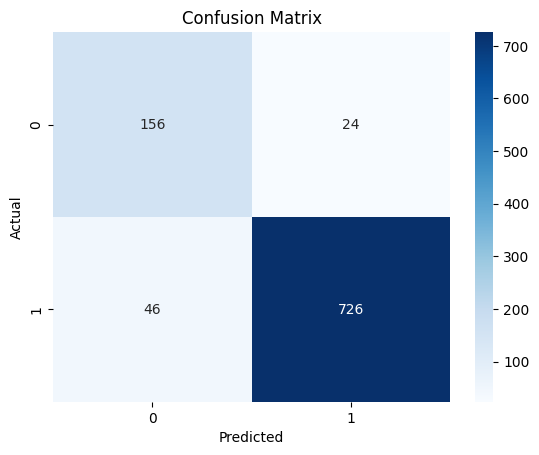

ROC Curve:


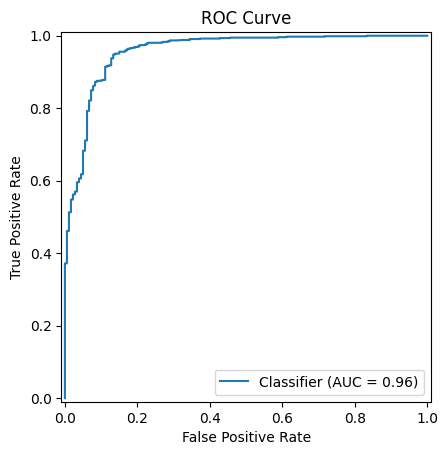

AUPRC Curve:


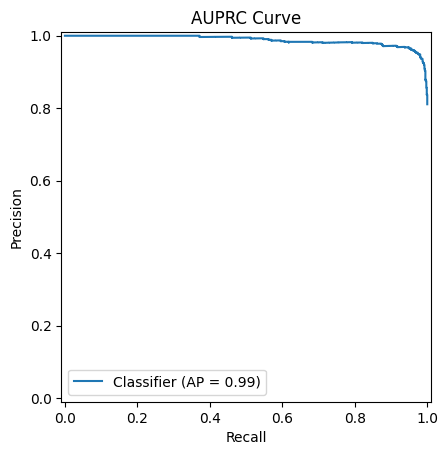

Model and metadata saved to saved_model/ml_models/
Final Stacking model saved as 'stacking_bioactivity_model.pkl'


In [83]:
best_params = study_final.best_params
scale_pos_weight_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
final_model_stacking = StackingClassifier(
    estimators=[
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ],

    final_estimator = LogisticRegression(
        C=best_params['meta_C'],
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
        solver=best_params['meta_solver'],
        penalty=best_params['meta_penalty'],
        tol=1e-4
    ) ,
    stack_method='predict_proba',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    passthrough=True
)

final_model_stacking.fit(X_train_full, y_train_full)
y_test_pred = final_model_stacking.predict(X_test)
y_test_pred_proba = final_model_stacking.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nFinal Stacking Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC: {final_auc:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("\n" + "="*80)
print("EVALUATING FINAL STACKING MODEL")
calc_metrics(final_model_stacking)
save_model(final_model_stacking, best_params, "stacking_bioactivity_model")
print("Final Stacking model saved as 'stacking_bioactivity_model.pkl'")

In [79]:
# ============================================================================
# 3. BAGGING CLASSIFIER
# ============================================================================

print("\n\n" + "="*70)
print("BAGGING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_bagging(trial):
    """
    Bagging Classifier with optimized base estimator
    """
    
    # Base estimator choice
    base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
    if base_estimator_type == 'dt':
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
            class_weight='balanced',
            random_state=42
        )
    elif base_estimator_type == 'svm':
        base_estimator = SVC(
            C=trial.suggest_float('svm_C', 0.1, 10, log=True),
            kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    else:  # knn
        base_estimator = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric='minkowski'
        )
    
    # Bagging parameters
    param = {
        'estimator': base_estimator,
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        'random_state': 42,
    }
    
    model = BaggingClassifier(**param)
    
    try:
        # Fit the model
        model.fit(X_train, y_train)
        
        # Get predictions
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC
        auc = roc_auc_score(y_val, preds_proba)
        
        return auc
    
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 0  # Return worst score on failure

study_bagging = optuna.create_study(
    direction="maximize",
    study_name="bagging_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Bagging Classifier optimization...")
study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("BAGGING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_bagging.best_params.items():
    print(f"  {key}: {value}")




[I 2025-11-22 00:15:46,703] A new study created in memory with name: bagging_optimization




BAGGING CLASSIFIER OPTIMIZATION
Starting Bagging Classifier optimization...


Best trial: 0. Best value: 0.948799:   3%|▎         | 1/30 [01:36<46:26, 96.10s/it]

[I 2025-11-22 00:17:22,799] Trial 0 finished with value: 0.9487988912842624 and parameters: {'base_estimator': 'svm', 'svm_C': 1.5751320499779735, 'svm_kernel': 'rbf', 'n_estimators': 15, 'max_samples': 0.9330880728874675, 'max_features': 0.8005575058716043, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 0 with value: 0.9487988912842624.


Best trial: 0. Best value: 0.948799:   7%|▋         | 2/30 [01:38<19:07, 40.97s/it]

...

[I 2025-11-22 00:25:41,297] Trial 27 finished with value: 0.9517666657334043 and parameters: {'base_estimator': 'dt', 'dt_max_depth': 20, 'dt_min_samples_split': 3, 'dt_min_samples_leaf': 4, 'n_estimators': 72, 'max_samples': 0.9244915385900426, 'max_features': 0.801611390106866, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541:  97%|█████████▋| 29/30 [25:47<04:54, 294.93s/it]

[I 2025-11-22 00:41:33,838] Trial 28 finished with value: 0.9242167595262759 and parameters: {'base_estimator': 'svm', 'svm_C': 0.18189366309739655, 'svm_kernel': 'rbf', 'n_estimators': 85, 'max_samples': 0.9732709746222247, 'max_features': 0.8837994836600225, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541: 100%|██████████| 30/30 [26:01<00:00, 52.07s/it] 

[I 2025-11-22 00:41:48,660] Trial 29 finished with value: 0.9159853851107316 and parameters: {'base_estimator': 'knn', 'knn_n_neighbors': 19, 'knn_weights': 'distance', 'n_estimators': 97, 'max_samples': 0.9065041611766789, 'max_features': 0.811933154502673, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.

BAGGING CLASSIFIER RESULTS
Best AUC: 0.0425

Best hyperparameters:
  base_estimator: dt
  dt_max_depth: 18
  dt_min_samples_split: 5
  dt_min_samples_leaf: 2
  n_estimators: 88
  max_samples: 0.8335260630715573
  max_features: 0.9272566041814421
  bootstrap: True
  bootstrap_features: True


In [80]:
best_params_bagging = study_bagging.best_params
final_model_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=best_params_bagging['dt_max_depth'],
        min_samples_split=best_params_bagging['dt_min_samples_split'],
        min_samples_leaf=best_params_bagging['dt_min_samples_leaf'],
        class_weight='balanced',
        random_state=42
    ),
    n_estimators=best_params_bagging['n_estimators'],
    max_samples=best_params_bagging['max_samples'],
    max_features=best_params_bagging['max_features'],
    bootstrap=best_params_bagging['bootstrap'],
    bootstrap_features=best_params_bagging['bootstrap_features'],
    random_state=42,
)

final_model_bagging.fit(X_train_full, y_train_full)
y_test_pred_bagging = final_model_bagging.predict(X_test)
y_test_pred_proba_bagging = final_model_bagging.predict_proba(X_test)[:, 1]
final_auc_bagging = roc_auc_score(y_test, y_test_pred_proba_bagging)
print(f"\nFinal Bagging Model Performance:")
print(f"AUC: {final_auc_bagging:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_bagging))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_bagging))



Final Bagging Model Performance:
AUC: 0.9607

Confusion Matrix:
[[143  37]
 [ 30 742]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       180
           1       0.95      0.96      0.96       772

    accuracy                           0.93       952
   macro avg       0.89      0.88      0.88       952
weighted avg       0.93      0.93      0.93       952



Accuracy: 0.9296
Balanced Acc.: 0.8778
Cohen's Kappa: 0.7670
Precision: 0.9525
Recall: 0.9611
F1 Score: 0.9568
ROC-AUC: 0.9607
AUPRC: 0.9882
MCC: 0.7672
NPV: 0.8266
Specificity: 0.7944
Sensitivity: 0.9611
Informedness: 0.7556
DOR: 95.5910
Brier Score: 0.0558
********************
Confusion Matrix:


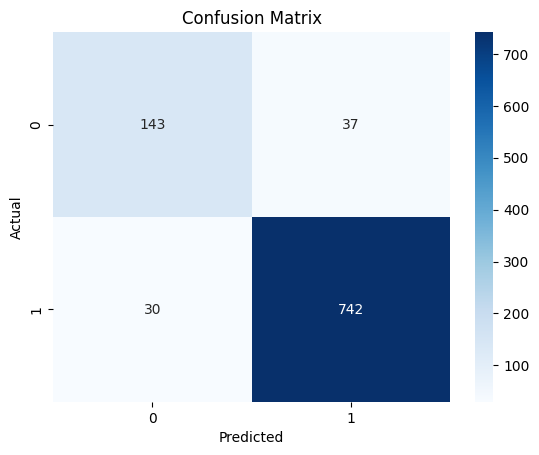

ROC Curve:


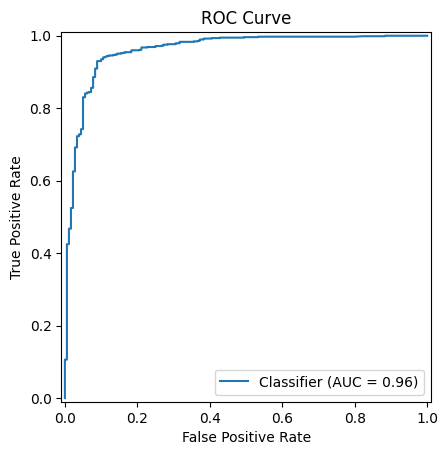

AUPRC Curve:


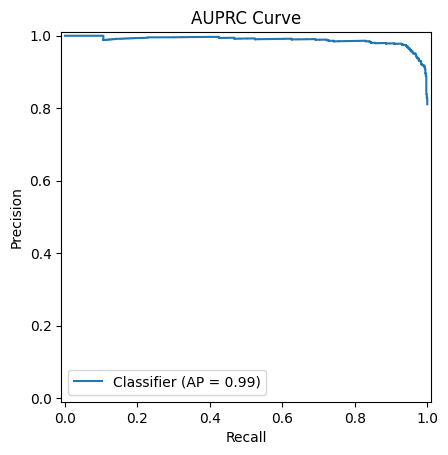

In [81]:
calc_metrics(final_model_bagging)